#Using Natural Language Processing to Simplify Medication Instruction

##Goal:This project uses natural language processing to simplify complex medication label instructions and evaluate whether the simplified text improves readibilty while also preserving the original meaning and important numerical information. 

#Data Loading and Utility Functions

The medication dataset is loaded into a pandas DataFrame with drug names, sections(dosage and warning), and original text instructions.
Custom utility functions from 'utils.py' are imported, to generate simplified versions of the medication instructions. 

In [14]:
#Import required libraries and utlity functions
#Pandas for data handling 
#Matplotlib for visualization
#sys and importlib for help load custom utility functions from utils.py file
#The simplify_text function is used to generate simplified medication instructions.

import sys, importlib
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append("..")

import src.utils as utils
importlib.reload(utils)

normalize_text = utils.normalize_text
simplify_text = utils.simplify_text




In [4]:
df = pd.read_csv("../data/processed/final_pipeline_ready.csv")

# Add data and verify dataset structure and contents
After creating dataset, did a quick check to verify number of columns and rows. Also checked to confirm that each drug had drug and warning section. Had a total of 20 drugs, each drug with dosage and warning. confirming 40 rows and 3 columns.

In [2]:
# Add data to the dataset
data = [
    
    {"Drug": "Adderall", 
     "Section": "Dosage",
     "Original_Text": """Regardless of indication, amphetamines should be administered at the lowest effective dosage, and dosage should be individually adjusted according to the therapeutic needs and response of the patient. Late evening doses should be avoided because of the resulting insomnia.

Attention Deficit Hyperactivity Disorder:
Not recommended for children under 3 years of age. In children from 3 to 5 years of age, start with 2.5 mg daily; daily dosage may be raised in increments of 2.5 mg at weekly intervals until optimal response is obtained.

In children 6 years of age and older, start with 5 mg once or twice daily; daily dosage may be raised in increments of 5 mg at weekly intervals until optimal response is obtained. Only in rare cases will it be necessary to exceed a total of 40 mg per day. Give first dose on awakening; additional doses (1 or 2) at intervals of 4 to 6 hours.

Prior to treating patients with Adderall, assess:

for the presence of cardiac disease (i.e., perform a careful history, family history of sudden death or ventricular arrhythmia, and physical exam).
the family history and clinically evaluate patients for motor or verbal tics or Tourette’s syndrome before initiating Adderall.
Narcolepsy:
Usual dose 5 mg to 60 mg per day in divided doses, depending on the individual patient response.

Narcolepsy seldom occurs in children under 12 years of age; however, when it does, dextroamphetamine sulfate may be used. The suggested initial dose for patients aged 6 to 12 is 5 mg daily; daily dose may be raised in increments of 5 mg at weekly intervals until optimal response is obtained. In patients 12 years of age and older, start with 10 mg daily; daily dosage may be raised in increments of 10 mg at weekly intervals until optimal response is obtained. If bothersome adverse reactions appear (e.g., insomnia or anorexia), dosage should be reduced. Give first dose on awakening; additional doses (1 or 2) at intervals of 4 to 6 hours."""
    },
        
    {"Drug": "Adderall", 
     "Section": "Warnings", 
     "Original_Text": """Abuse, Misuse, and Addiction
Adderall has a high potential for abuse and misuse. The use of Adderall exposes individuals to the risks of abuse and misuse, which can lead to the development of a substance use disorder, including addiction. Adderall can be diverted for non-medical use into illicit channels or distribution. Misuse and abuse of CNS stimulants, including Adderall, can result in overdose and death, and this risk is increased with higher doses or unapproved methods of administration, such as snorting or injection.

Before prescribing Adderall® assess each patient’s risk for abuse, misuse, and addiction. Educate patients and their families about these risks and proper disposal of any unused drug. Advise patients to store amphetamine sulfate in a safe place, preferably locked, and instruct patients to not give Adderall to anyone else. Throughout Adderall treatment, reassess each patient’s risk of abuse, misuse, and addiction and frequently monitor for signs and symptoms of abuse, misuse, and addiction.

Risks to Patients with Serious Cardiac Disease:
Sudden death has been reported in patients with structural cardiac abnormalities or other serious cardiac disease who were treated with CNS stimulant treatment at the recommended ADHD dosages.

Avoid Adderall use in patients with known structural cardiac abnormalities, cardiomyopathy, serious cardiac arrhythmia, coronary artery disease, or other serious cardiac disease.

Increased Blood Pressure and Heart Rate:
CNS stimulants cause an increase in blood pressure (mean increase about 2 to 4 mm Hg) and heart rate (mean increase about 3 to 6 bpm). Some patients may have larger increases. Monitor all Adderall®-treated patients for potential tachycardia and hypertension.

Psychiatric Adverse Reactions:
Exacerbation of Preexisting Psychosis
CNS stimulants may exacerbate symptoms of behavior disturbance and thought disorder in patients with a pre-existing psychotic disorder.

Induction of a Manic Episode in Patients with Bipolar Disorder:
CNS stimulants may induce a manic or mixed episode in patients. Prior to initiating treatment, screen patients for risk factors for developing a manic episode (e.g., comorbid or history of depressive symptoms or a family history of suicide, bipolar disorder, or depression).

New Psychotic or Manic Symptoms:
CNS stimulants, at recommended doses, may cause psychotic or manic symptoms (e.g., hallucinations, delusional thinking, or mania) in patients without a prior history of psychotic illness or mania. 
Long-Term Suppression of Growth in Pediatric Patients:
CNS stimulants have been associated with weight loss and slowing of growth rate in pediatric patients. Closely monitor growth (weight and height) in Adderall-treated pediatric patients treated with CNS stimulants.

Pediatric patients who are not growing or gaining weight as expected may need to have their treatment interrupted.

Seizures:
There is some clinical evidence that stimulants may lower the convulsive threshold in patients with prior history of seizure, in patients with prior EEG abnormalities in absence of seizures, and very rarely, in patients without a history of seizures and no prior EEG evidence of seizures. In the presence of seizures, the drug should be discontinued.

Peripheral Vasculopathy, Including Raynaud’s Phenomenon:
Stimulants, including Adderall®, used to treat ADHD are associated with peripheral vasculopathy, including Raynaud’s phenomenon. Signs and symptoms are usually intermittent and mild; however, sequelae include digital ulceration and/or soft tissue breakdown. Effects of peripheral vasculopathy, including Raynaud’s phenomenon, were observed in postmarketing reports and at the therapeutic dosage of CNS stimulants in all age groups throughout the course of treatment. Signs and symptoms generally improved after dosage reduction or discontinuation of the CNS stimulant. Careful observation for digital changes is necessary during Adderall® treatment. Further clinical evaluation (e.g., rheumatology referral) may be appropriate for Adderall®-treated patients who develop signs or symptoms of peripheral vasculopathy.

Serotonin Syndrome:
Serotonin syndrome, a potentially life-threatening reaction, may occur when amphetamines are used in combination with other drugs that affect the serotonergic neurotransmitter systems such as monoamine oxidase inhibitors (MAOIs), selective serotonin reuptake inhibitors (SSRIs), serotonin norepinephrine reuptake inhibitors (SNRIs), triptans, tricyclic antidepressants, fentanyl, lithium, tramadol, tryptophan, buspirone, and St. John’s Wort.

Serotonin syndrome symptoms may include mental status changes (e.g., agitation, hallucinations, delirium, and coma), autonomic instability (e.g., tachycardia, labile blood pressure, dizziness, diaphoresis, flushing, hyperthermia), neuromuscular symptoms (e.g., tremor, rigidity, myoclonus, hyperreflexia, incoordination), seizures, and/or gastrointestinal symptoms (e.g., nausea, vomiting, diarrhea).

Concomitant use of Adderall with MAOI drugs is contraindicated:

Discontinue treatment with Adderall and any concomitant serotonergic agents immediately if the above symptoms occur, and initiate supportive symptomatic treatment. If concomitant use of Adderall with other serotonergic drugs or CYP2D6 inhibitors is clinically warranted, initiate Adderall with lower doses, monitor patients for the emergence of serotonin syndrome during drug initiation or titration, and inform patients of the increased risk for serotonin syndrome.

Motor and Verbal Tics, and Worsening of Tourette’s Syndrome:
CNS stimulants, including amphetamine sulfate, have been associated with the onset or exacerbation of motor and verbal tics. Worsening of Tourette’s syndrome has also been reported. Before initiating Adderall, assess the family history and clinically evaluate patients for tics or Tourette’s syndrome. Regularly monitor patients for the emergence or worsening of tics or Tourette’s syndrome with Adderall®, and discontinue treatment if clinically appropriate."""},


# Add Alprazolam data
    {"Drug": "Alprazolam", 
     "Section": "Dosage", 
     "Original_Text": """Administer alprazolam extended-release tablets orally once daily, preferably in the morning. Swallow tablets whole; do not divide, crush, or chew.

The recommended starting oral dosage for alprazolam extended-release tablets is 0.5 mg to 1 mg once daily. Depending on the response, the dosage may be adjusted at intervals of every 3 to 4 days in increments of no more than 1 mg daily. The recommended dosage range is 3 mg to 6 mg once daily.

Controlled trials of alprazolam extended-release tablets for the treatment of panic disorder included dosages in the range of 1 mg to 10 mg per day. Most patients showed a response in the dosage range of 3 mg to 6 mg per day. Occasional patients required as much as 10 mg per day.

The longer-term efficacy of alprazolam extended-release tablets has not been systematically evaluated. If alprazolam extended-release tablets is used for periods longer than 8 weeks, the healthcare provider should periodically reassess the usefulness of the drug for the individual patient.

After a period of extended freedom from panic attacks, a carefully supervised tapered discontinuation may be attempted, but there is evidence that this may often be difficult to accomplish without recurrence of symptoms and/or the manifestation of withdrawal phenomena.

Discontinuation or Dosage Reduction of Alprazolam Extended-Release Tablets:
To reduce the risk of withdrawal reactions, use a gradual taper to discontinue alprazolam extended-release tablets or reduce the dosage. If a patient develops withdrawal reactions, consider pausing the taper or increasing the dosage to the previous tapered dosage level. Subsequently decrease the dosage more slowly.

Reduce the dosage by no more than 0.5 mg every three days. Some patients may benefit from an even more gradual discontinuation. Some patients may prove resistant to all discontinuation regimens.

In a controlled postmarketing discontinuation study of panic disorder patients which compared the recommended taper schedule with a slower taper schedule, no difference was observed between the groups in the proportion of patients who tapered to zero dose; however, the slower schedule was associated with a reduction in symptoms associated with a withdrawal syndrome.

Dosage Recommendations in Geriatric Patients:
In geriatric patients, the recommended starting dosage of alprazolam extended-release tablets is 0.5 mg once daily. This may be gradually increased if needed and tolerated. Geriatric patients may be sensitive to the effects of benzodiazepines. 

Dosage Recommendations in Patients with Hepatic Impairment:
In patients with hepatic impairment, the recommended starting dosage of alprazolam extended-release tablets is 0.5 mg once daily. This may be gradually increased if needed and tolerated.

Dosage Modifications for Drug Interactions:
Alprazolam extended-release tablets should be reduced to half of the recommended dosage when a patient is started on ritonavir and alprazolam extended-release tablets together, or when ritonavir is added to a patient treated with alprazolam extended-release tablets. Increase alprazolam extended-release tablets dosage to the target dose after 10 to 14 days of dosing ritonavir and alprazolam extended-release tablets together. It is not necessary to reduce alprazolam extended-release tablets dosage in patients who have been taking ritonavir for more than 10 to 14 days.

Alprazolam extended-release tablets are contraindicated with concomitant use of all strong CYP3A inhibitors, except ritonavir. 

Switching Patients from Alprazolam Tablets to Alprazolam Extended-Release Tablets:
Patients who are currently being treated with divided doses of alprazolam tablets may be switched to alprazolam extended-release tablets at the same total daily dose taken once daily. If the clinical response after switching is inadequate, titrate the dosage as outlined above. 
Patients who are currently being treated with a single daily dose of alprazolam tablets may be switched to alprazolam extended-release tablets at the same total daily dose taken once daily. If the clinical response after switching is inadequate, titrate the dosage as outlined above."""},
    
    {"Drug": "Alprazolam",
    "Section": "Warnings",
    "Original_Text": """ Risks from Concomitant Use with Opioids:
Concomitant use of benzodiazepines, including alprazolam extended-release tablets, and opioids may result in profound sedation, respiratory depression, coma, and death. Because of these risks, reserve concomitant prescribing of these drugs in patients for whom alternative treatment options are inadequate.

Observational studies have demonstrated that concomitant use of opioid analgesics and benzodiazepines increases the risk of drug-related mortality compared to use of opioids alone. If a decision is made to prescribe alprazolam extended-release tablets concomitantly with opioids, prescribe the lowest effective dosages and minimum durations of concomitant use, and follow patients closely for signs and symptoms of respiratory depression and sedation. In patients already receiving an opioid analgesic, prescribe a lower initial dose of alprazolam extended-release tablets than indicated in the absence of an opioid and titrate based on clinical response. If an opioid is initiated in a patient already taking alprazolam extended-release tablets, prescribe a lower initial dose of the opioid and titrate based upon clinical response.

Advise both patients and caregivers about the risks of respiratory depression and sedation when alprazolam extended-release tablets is used with opioids. Advise patients not to drive or operate heavy machinery until the effects of concomitant use with the opioid have been determined.

Abuse, Misuse, and Addiction:
The use of benzodiazepines, including alprazolam extended-release tablets, exposes users to the risks of abuse, misuse, and addiction, which can lead to overdose or death. Abuse and misuse of benzodiazepines often (but not always) involve the use of doses greater than the maximum recommended dosage and commonly involve concomitant use of other medications, alcohol, and/or illicit substances, which is associated with an increased frequency of serious adverse outcomes, including respiratory depression, overdose, or death.

Before prescribing alprazolam extended-release tablets and throughout treatment, assess each patient’s risk for abuse, misuse, and addiction (e.g., using a standardized screening tool). Use of alprazolam extended-release tablets, particularly in patients at elevated risk, necessitates counseling about the risks and proper use of alprazolam extended-release tablets along with monitoring for signs and symptoms of abuse, misuse, and addiction. Prescribe the lowest effective dosage; avoid or minimize concomitant use of CNS depressants and other substances associated with abuse, misuse, and addiction (e.g., opioid analgesics, stimulants); and advise patients on the proper disposal of unused drug. If a substance use disorder is suspected, evaluate the patient and institute (or refer them for) early treatment, as appropriate.

Dependence and Withdrawal Reactions:
To reduce the risk of withdrawal reactions, use a gradual taper to discontinue alprazolam extended-release tablets or reduce the dosage (a patient-specific plan should be used to taper the dose).

Patients at an increased risk of withdrawal adverse reactions after benzodiazepine discontinuation or rapid dosage reduction include those who take higher dosages, and those who have had longer durations of use.

Acute Withdrawal Reactions:

The continued use of benzodiazepines, including alprazolam extended-release tablets, may lead to clinically significant physical dependence. Abrupt discontinuation or rapid dosage reduction of alprazolam extended-release tablets after continued use, or administration of flumazenil (a benzodiazepine antagonist) may precipitate acute withdrawal reactions, which can be life-threatening (e.g., seizures).

Protracted Withdrawal Syndrome:

In some cases, benzodiazepine users have developed a protracted withdrawal syndrome with withdrawal symptoms lasting weeks to more than 12 months.

Certain adverse clinical events, some life-threatening, are a direct consequence of physical dependence to alprazolam extended-release tablets. These include a spectrum of withdrawal symptoms; the most important is seizure [see Drug Abuse and Dependence (9.3)]. Even after relatively short-term use at doses of ≤ 4 mg/day, there is some risk of dependence. Spontaneous reporting system data suggest that the risk of dependence and its severity appear to be greater in patients treated with doses greater than 4 mg/day and for long periods (more than 12 weeks). However, in a controlled postmarketing discontinuation study of panic disorder patients who received alprazolam, the duration of treatment (3 months compared to 6 months) had no effect on the ability of patients to taper to zero dose. In contrast, patients treated with doses of alprazolam greater than 4 mg/day had more difficulty tapering to zero dose than those treated with less than 4 mg/day.

In a controlled clinical trial in which 63 patients were randomized to alprazolam and where withdrawal symptoms were specifically sought, the following were identified as symptoms of withdrawal: heightened sensory perception, impaired concentration, dysosmia, clouded sensorium, paresthesias, muscle cramps, muscle twitch, diarrhea, blurred vision, appetite decrease, and weight loss. Other symptoms, such as anxiety and insomnia, were frequently seen during discontinuation, but it could not be determined if they were due to return of illness, rebound, or withdrawal.

Interdose Symptoms:

Early morning anxiety and emergence of anxiety symptoms between doses of alprazolam have been reported in patients with panic disorder taking prescribed maintenance doses. These symptoms may reflect the development of tolerance or a time interval between doses which is longer than the duration of clinical action of the administered dose. In either case, it is presumed that the prescribed dose is not sufficient to maintain plasma levels above those needed to prevent relapse, rebound, or withdrawal symptoms over the entire course of the interdosing interval.

Effects on Driving and Operating Machinery:
Because of its CNS depressant effects, patients receiving alprazolam extended-release tablets should be cautioned against engaging in hazardous occupations or activities requiring complete mental alertness such as operating machinery or driving a motor vehicle. For the same reason, patients should be cautioned about the concomitant use of alcohol and other CNS depressant drugs during treatment with alprazolam extended-release tablets [see Drug Interactions (7.1)]. 


Patients with Depression:
Benzodiazepines may worsen depression. Panic disorder has been associated with primary and secondary major depressive disorders and increased reports of suicide among untreated patients. Consequently, appropriate precautions (e.g., limiting the total prescription size and increased monitoring for suicidal ideation) should be considered in patients with depression.

Mania:
Episodes of hypomania and mania have been reported in association with the use of alprazolam extended-release tablets in patients with depression.

Neonatal Sedation and Withdrawal Syndrome:
Use of alprazolam extended-release tablets late in pregnancy can result in sedation (respiratory depression, lethargy, hypotonia) and/or withdrawal symptoms (hyperreflexia, irritability, restlessness, tremors, inconsolable crying, and feeding difficulties) in the neonate. Monitor neonates exposed to alprazolam extended-release tablets during pregnancy or labor for signs of sedation and monitor neonates exposed to alprazolam extended-release tablets during pregnancy for signs of withdrawal; manage these neonates accordingly.

Risks in Patients with Impaired Respiratory Function:
There have been reports of death in patients with severe pulmonary disease shortly after the initiation of treatment with alprazolam. Closely monitor patients with impaired respiratory function. If signs and symptoms of respiratory depression, hypoventilation, or apnea occur, discontinue alprazolam extended-release tablets."""},

# Add Metoprolol data
    {"Drug": "Metoprolol", 
     "Section": "Dosage", 
     "Original_Text": """Hypertension
Adults: The usual initial dosage is 25 mg to 100 mg once daily in a single dose. Adjust dosage at weekly (or longer) intervals until optimum blood pressure reduction is achieved. Dosages above 400 mg per day have not been studied.

Pediatric Hypertensive Patients 6 Years of age or older: The recommended starting dose of metoprolol succinate extended-release capsules is 1 mg/kg once daily, the maximum initial dose should not exceed 50 mg once daily. Adjust dosage according to blood pressure response. Doses above 2 mg/kg (or in excess of 200 mg) once daily have not been studied in pediatric patients.

Metoprolol succinate extended-release capsules has not been studied in pediatric patients less than 6 years of age.
Angina Pectoris:
Individualize the dosage of metoprolol succinate extended-release capsules. The usual initial dosage is 100 mg once daily, given in a single dose. Gradually increase the dosage at weekly intervals until optimum clinical response has been obtained or there is a pronounced slowing of the heart rate. Dosages above 400 mg per day have not been studied. If treatment is to be discontinued, reduce the dosage gradually over a period of 1 to 2 weeks.

Heart Failure:
Prior to initiation of metoprolol succinate extended-release capsules, stabilize the dose of other heart failure drug therapy and ensure that the patient is not fluid overloaded. The recommended starting dose of metoprolol succinate extended-release capsules is 25 mg once daily for two weeks. Metoprolol succinate extended-release capsules are not suitable for initial therapy in patients who are expected to require a starting dose less than 25 mg daily. Dosage must be individualized and closely monitored during up-titration. Double the dose every two weeks to the highest dosage level tolerated by the patient or up to 200 mg of metoprolol succinate extended-release capsules. If a patient experiences symptomatic bradycardia, reduce the dose of metoprolol succinate extended-release capsules. If transient worsening of heart failure occurs, consider treating with increased doses of diuretics, lowering the dose of metoprolol succinate extended-release capsules or temporarily discontinuing it. The dose of metoprolol succinate extended-release capsules should not be increased until symptoms of worsening heart failure have been stabilized. Initial difficulty with titration should not preclude later attempts to introduce metoprolol succinate extended-release capsules.

For patients who are taking metoprolol succinate extended-release tablets at a dose of 25 mg to 200 mg once daily, substitute metoprolol succinate extended-release capsules for metoprolol succinate extended-release tablets, using the same total daily dose of metoprolol succinate in mg.

Administration:
Metoprolol succinate extended-release capsules should be swallowed whole. For patients unable to swallow an intact capsule, alternative administration options are available.

Directions for use with soft food (applesauce, pudding, or yogurt)

For patients with swallowing difficulty, Metoprolol succinate extended-release capsules can be opened and contents can be sprinkled over soft food. The contents of the capsules should be swallowed along with a small amount (teaspoonful) of soft food (such as applesauce, pudding, or yogurt). The drug/food mixture should be swallowed within 60 minutes and not stored for future use.

Nasogastric tube administration:

Open and add content of capsule to an all plastic oral tip syringe and add 15 mL of water. Gently shake the syringe for approx. 10 sec to help suspend the granules and promptly deliver through a 12 French or larger nasogastric tube. No granules should be left in the syringe, rinse as required."""
    },
    {
        "Drug": "Metoprolol",
        "Section": "Warnings",
        "Original_Text": """Abrupt Cessation of Therapy:
Following abrupt cessation of therapy with certain beta-blocking agents, exacerbations of angina pectoris and, in some cases, myocardial infarction have occurred. When discontinuing chronically administered metoprolol succinate, particularly in patients with ischemic heart disease, gradually reduce the dosage over a period of 1 to 2 weeks and monitor the patient. If angina markedly worsens or acute coronary ischemia develops, promptly reinstate metoprolol succinate, and take measures appropriate for the management of unstable angina. Warn patients not to interrupt therapy without their physician’s advice. Because coronary artery disease is common and may be unrecognized, avoid abruptly discontinuing metoprolol succinate in patients treated only for hypertension.

Heart Failure:
Worsening cardiac failure may occur during up-titration of metoprolol succinate. If such symptoms occur, increase diuretics and restore clinical stability before advancing the dose of metoprolol succinate. It may be necessary to lower the dose of metoprolol succinate or temporarily discontinue it. Such episodes do not preclude subsequent successful titration of metoprolol succinate.

Bronchospastic Disease:
PATIENTS WITH BRONCHOSPASTIC DISEASES SHOULD, IN GENERAL, NOT RECEIVE BETA-BLOCKERS. Because of its relative beta1 cardio-selectivity, however, metoprolol succinate may be used in patients with bronchospastic disease who do not respond to, or cannot tolerate, other antihypertensive treatment. Because beta1-selectivity is not absolute, use the lowest possible dose of metoprolol succinate. Bronchodilators, including beta2-agonists, should be readily available or administered concomitantly.

Pheochromocytoma:
If metoprolol succinate is used in the setting of pheochromocytoma, it should be given in combination with an alpha blocker, and only after the alpha blocker has been initiated. Administration of beta-blockers alone in the setting of pheochromocytoma has been associated with a paradoxical increase in blood pressure due to the attenuation of beta-mediated vasodilatation in skeletal muscle.

Major Surgery:
Avoid initiation of a high-dose regimen of extended-release metoprolol in patients undergoing non-cardiac surgery, since such use in patients with cardiovascular risk factors has been associated with bradycardia, hypotension, stroke and death.

Chronically administered beta-blocking therapy should not be routinely withdrawn prior to major surgery, however, the impaired ability of the heart to respond to reflex adrenergic stimuli may augment the risks of general anesthesia and surgical procedures.
Masked Symptoms of Hypoglycemia:
Beta-blockers may mask tachycardia occurring with hypoglycemia, but other manifestations such as dizziness and sweating may not be significantly affected.

Thyrotoxicosis:
Beta-adrenergic blockade may mask certain clinical signs of hyperthyroidism, such as tachycardia. Abrupt withdrawal of beta-blockade may precipitate a thyroid storm.

Peripheral Vascular Disease:
Beta-blockers can precipitate or aggravate symptoms of arterial insufficiency in patients with peripheral vascular disease."""},

# Add Ozempic data
    {"Drug": "Ozempic", 
     "Section": "Dosage", 
     "Original_Text": """Important Administration Instructions:

Inspect OZEMPIC visually before use. It should appear clear and colorless. Do not use OZEMPIC if particulate matter and coloration is seen.

Administer OZEMPIC once weekly, on the same day each week, at any time of the day, with or without meals.

Inject OZEMPIC subcutaneously in the abdomen, thigh, or upper arm. Instruct patients to use a different injection site each week when injecting in the same body region.

When using OZEMPIC with insulin, instruct patients to administer as separate injections and to never mix the products. It is acceptable to inject OZEMPIC and insulin in the same body region, but the injections should not be adjacent to each other.

The day of weekly administration can be changed if necessary as long as the time between two doses is at least 2 days (>48 hours).

If a dose is missed, administer OZEMPIC as soon as possible within 5 days after the missed dose. If more than 5 days have passed, skip the missed dose and administer the next dose on the regularly scheduled day. In each case, patients can then resume their regular once-weekly dosing schedule.
Recommended Dosage:
Recommended Initiation Dosage:

Initiate OZEMPIC with a dosage of 0.25 mg injected subcutaneously once weekly for 4 weeks. Follow the dosage escalation below to reduce the risk of gastrointestinal adverse reactions.

After 4 weeks on the 0.25 mg dosage, increase the dosage to 0.5 mg once weekly.

Recommended Maintenance and Maximum Dosages for Glycemic Control:

The recommended maintenance dosage is 0.5 mg, 1 mg, or 2 mg, injected subcutaneously once weekly, based on glycemic control.

If additional glycemic control is needed after at least 4 weeks on the:

0.5 mg dosage, the dosage may be increased to 1 mg once weekly.
1 mg dosage, the dosage may be increased to 2 mg once weekly.
The maximum recommended dosage is 2 mg once weekly.

Recommended Maintenance Dosage in Patients with Type 2 Diabetes Mellitus and Chronic Kidney Disease:

Increase the dosage to the maintenance dosage, 1 mg once weekly, after at least 4 weeks on the 0.5 mg dosage."""
    },
    {
        "Drug": "Ozempic",
        "Section": "Warnings",
        "Original_Text": """ Risk of Thyroid C-Cell Tumors:
In mice and rats, semaglutide caused a dose-dependent and treatment-duration-dependent increase in the incidence of thyroid C-cell tumors (adenomas and carcinomas) after lifetime exposure at clinically relevant plasma exposures. It is unknown whether OZEMPIC causes thyroid C-cell tumors, including MTC, in humans as human relevance of semaglutide-induced rodent thyroid C-cell tumors has not been determined.

Cases of MTC in patients treated with liraglutide, another GLP-1 receptor agonist, have been reported in the postmarketing period; the data in these reports are insufficient to establish or exclude a causal relationship between MTC and GLP-1 receptor agonist use in humans.

OZEMPIC is contraindicated in patients with a personal or family history of MTC or in patients with MEN 2. Counsel patients regarding the potential risk for MTC with the use of OZEMPIC and inform them of symptoms of thyroid tumors (e.g., a mass in the neck, dysphagia, dyspnea, persistent hoarseness).

Routine monitoring of serum calcitonin or using thyroid ultrasound is of uncertain value for early detection of MTC in patients treated with OZEMPIC. Such monitoring may increase the risk of unnecessary procedures, due to the low-test specificity for serum calcitonin and a high background incidence of thyroid disease. Significantly elevated serum calcitonin value may indicate MTC and patients with MTC usually have calcitonin values >50 ng/L. If serum calcitonin is measured and found to be elevated, the patient should be further evaluated. Patients with thyroid nodules noted on physical examination or neck imaging should also be further evaluated.

Acute Pancreatitis:
Acute pancreatitis, including fatal and non-fatal hemorrhagic or necrotizing pancreatitis, has been observed in patients treated with GLP-1 receptor agonists, including semaglutide:

After initiation of OZEMPIC, observe patients carefully for signs and symptoms of acute pancreatitis which may include persistent or severe abdominal pain (sometimes radiating to the back) and which may or may not be accompanied by nausea or vomiting. If pancreatitis is suspected, discontinue OZEMPIC and initiate appropriate management.

Diabetic Retinopathy Complications:
In a 2-year trial involving patients with type 2 diabetes and high cardiovascular risk, more events of diabetic retinopathy complications occurred in patients treated with OZEMPIC (3.0%) compared to placebo (1.8%). The absolute risk increase for diabetic retinopathy complications was larger among patients with a history of diabetic retinopathy at baseline (OZEMPIC 8.2%, placebo 5.2%) than among patients without a known history of diabetic retinopathy.

Rapid improvement in glucose control has been associated with a temporary worsening of diabetic retinopathy. The effect of long-term glycemic control with semaglutide on diabetic retinopathy complications has not been studied. Patients with a history of diabetic retinopathy should be monitored for progression of diabetic retinopathy.

Never Share an OZEMPIC Pen Between Patients:
OZEMPIC pens must never be shared between patients, even if the needle is changed. Pen-sharing poses a risk for transmission of blood-borne pathogens.

Hypoglycemia with Concomitant Use of Insulin Secretagogues or Insulin:
Patients receiving OZEMPIC in combination with an insulin secretagogue (e.g., sulfonylurea) or insulin may have an increased risk of hypoglycemia, including severe hypoglycemia.

The risk of hypoglycemia may be lowered by a reduction in the dose of sulfonylurea (or other concomitantly administered insulin secretagogue) or insulin. Inform patients using these concomitant medications of the risk of hypoglycemia and educate them on the signs and symptoms of hypoglycemia.

Acute Kidney Injury Due to Volume Depletion:
There have been postmarketing reports of acute kidney injury, in some cases requiring hemodialysis, in patients treated with semaglutide. The majority of the reported events occurred in patients who experienced gastrointestinal reactions leading to dehydration such as nausea, vomiting, or diarrhea. Monitor renal function in patients reporting adverse reactions to OZEMPIC that could lead to volume depletion, especially during dosage initiation and escalation of OZEMPIC.

Severe Gastrointestinal Adverse Reactions:
Use of OZEMPIC has been associated with gastrointestinal adverse reactions, sometimes severe. In OZEMPIC clinical trials, severe gastrointestinal adverse reactions were reported more frequently among patients receiving OZEMPIC (0.5 mg 0.4%, 1 mg 0.8%) than placebo (0%). Severe gastrointestinal adverse reactions have also been reported postmarketing with GLP-1 receptor agonists.

OZEMPIC is not recommended in patients with severe gastroparesis.

Hypersensitivity Reactions:
Serious hypersensitivity reactions (e.g., anaphylaxis, angioedema) have been reported in patients treated with OZEMPIC. If hypersensitivity reactions occur, discontinue use of OZEMPIC; treat promptly per standard of care, and monitor until signs and symptoms resolve. Do not use in patients with a previous hypersensitivity to OZEMPIC.

Anaphylaxis and angioedema have been reported with other GLP-1 receptor agonists. Use caution in a patient with a history of angioedema or anaphylaxis with another GLP-1 receptor agonist because it is unknown whether such patients will be predisposed to anaphylaxis with OZEMPIC.

Acute Gallbladder Disease:
Acute events of gallbladder disease such as cholelithiasis or cholecystitis have been reported in GLP-1 receptor agonist trials and postmarketing. In placebo-controlled trials, cholelithiasis was reported in 1.5% and 0.4% of patients-treated with OZEMPIC 0.5 mg and 1 mg, respectively. Cholelithiasis was not reported in placebo-treated patients. If cholelithiasis is suspected, gallbladder studies and appropriate clinical follow-up are indicated.

Pulmonary Aspiration During General Anesthesia or Deep Sedation:
OZEMPIC delays gastric emptying. There have been rare postmarketing reports of pulmonary aspiration in patients receiving GLP-1 receptor agonists undergoing elective surgeries or procedures requiring general anesthesia or deep sedation who had residual gastric contents despite reported adherence to preoperative fasting recommendations.

Available data are insufficient to inform recommendations to mitigate the risk of pulmonary aspiration during general anesthesia or deep sedation in patients taking OZEMPIC, including whether modifying preoperative fasting recommendations or temporarily discontinuing OZEMPIC could reduce the incidence of retained gastric contents. Instruct patients to inform healthcare providers prior to any planned surgeries or procedures if they are taking OZEMPIC."""},

#Add Humira data
    {"Drug": "Humira", 
     "Section": "Dosage", 
     "Original_Text": """Recommended Tuberculosis Evaluation
Prior to initiating HUMIRA and periodically during therapy, evaluate patients for active tuberculosis and test for latent infection. 

Recommended Dosage in Rheumatoid Arthritis, Psoriatic Arthritis, and Ankylosing Spondylitis:
The recommended subcutaneous dosage of HUMIRA for adult patients with rheumatoid arthritis (RA), psoriatic arthritis (PsA), or ankylosing spondylitis (AS) is 40 mg administered every other week. Methotrexate (MTX), other non-biologic DMARDS, glucocorticoids, nonsteroidal anti-inflammatory drugs (NSAIDs), and/or analgesics may be continued during treatment with HUMIRA. In the treatment of RA, some patients not taking concomitant MTX may derive additional benefit from increasing the dosage of HUMIRA to 40 mg every week or 80 mg every other week. 

Recommended Dosage in Juvenile Idiopathic Arthritis or Pediatric Patients with Uveitis:
The recommended subcutaneous dosage of HUMIRA for pediatric patients 2 years of age and older with polyarticular juvenile idiopathic arthritis (JIA) or pediatric uveitis [see Indications and Usage (1.2, 1.9)], based on weight, is shown below. MTX, glucocorticoids, NSAIDs, and/or analgesics may be continued during treatment with HUMIRA. 
HUMIRA has not been studied in patients with polyarticular JIA or pediatric uveitis less than 2 years of age or in patients with a weight below 10 kg.

Recommended Dosage in Crohn’s Disease: 
Subcutaneous Adult Dosage Regimen

The recommended subcutaneous dosage of HUMIRA for adult patients with moderately to severely active Crohn’s disease (CD) is 160 mg initially on Day 1 (given in one day or split over two consecutive days), followed by 80 mg two weeks later (Day 15). Two weeks later (Day 29) begin a dosage of 40 mg every other week. Aminosalicylates and/or corticosteroids may be continued during treatment with HUMIRA. Azathioprine, 6-mercaptopurine (6-MP) or MTX may be continued during treatment with HUMIRA if necessary.

Subcutaneous Pediatric Dosage Regimen:

The recommended subcutaneous dosage of HUMIRA for pediatric patients 6 years of age and older with moderately to severely active Crohn’s disease (CD), based on body weight, is shown below:
Recommended Dosage in Ulcerative Colitis 
Subcutaneous Adult Dosage Regimen

The recommended subcutaneous dosage of HUMIRA for adult patients with moderately to severely active ulcerative colitis is 160 mg initially on Day 1 (given in one day or split over two consecutive days), followed by 80 mg two weeks later (Day 15). Two weeks later (Day 29) continue with a dosage of 40 mg every other week.

Discontinue HUMIRA in adult patients without evidence of clinical remission by eight weeks (Day 57) of therapy. Aminosalicylates and/or corticosteroids may be continued during treatment with HUMIRA. Azathioprine and 6-mercaptopurine (6-MP) may be continued during treatment with HUMIRA if necessary.

Subcutaneous Pediatric Dosage Regimen:

The recommended subcutaneous dosage of HUMIRA for pediatric patients 5 years of age and older with moderately to severely active ulcerative colitis, based on body weight, is shown below:
Recommended Dosage in Plaque Psoriasis or Adults with Uveitis 
The recommended subcutaneous dosage of HUMIRA for adult patients with plaque psoriasis (Ps) or uveitis (UV) [see Indications and Usage (1.7, 1.9)] is an initial dose of 80 mg, followed by 40 mg given every other week starting one week after the initial dose. The use of HUMIRA in moderate to severe chronic Ps beyond one year has not been evaluated in controlled clinical studies.

Recommended Dosage in Hidradenitis Suppurativa: 
Subcutaneous Adult Dosage Regimen

The recommended subcutaneous dosage of HUMIRA for adult patients with moderate to severe hidradenitis suppurativa (HS) is an initial dose of 160 mg (given in one day or split over two consecutive days), followed by 80 mg two weeks later (Day 15). Begin 40 mg weekly or 80 mg every other week dosing two weeks later (Day 29).

Subcutaneous Pediatric Dosage Regimen:

The recommended subcutaneous dosage of HUMIRA for pediatric patients 12 years of age and older weighing at least 30 kg with moderate to severe hidradenitis suppurativa (HS), based on body weight, is shown below:
General Considerations for Administration
HUMIRA is intended for use under the guidance and supervision of a physician. A patient may self-inject HUMIRA or a caregiver may inject HUMIRA using either the HUMIRA Pen or prefilled syringe if a physician determines that it is appropriate, and with medical follow-up, as necessary, after proper training in subcutaneous injection technique.

HUMIRA can be taken out of the refrigerator for 15 to 30 minutes before injecting to allow the liquid to come to room temperature. Do not remove the cap or cover while allowing it to reach room temperature. Carefully inspect the solution in the HUMIRA Pen or prefilled syringe for particulate matter and discoloration prior to subcutaneous administration. If particulates and discolorations are noted, do not use the product. HUMIRA does not contain preservatives; therefore, discard unused portions of drug remaining from the syringe. NOTE: Instruct patients sensitive to latex not to handle the needle cover of the HUMIRA 40 mg/0.8 mL Pen and 40 mg/0.8 mL prefilled syringe because it may contain natural rubber latex.

Instruct patients using the HUMIRA Pen or prefilled syringe to inject the full amount in the syringe, according to the directions provided in the Instructions for Use.

Injections should occur at separate sites in the thigh or abdomen. Rotate injection sites and do not give injections into areas where the skin is tender, bruised, red or hard.

If a dose is missed, administer the dose as soon as possible. Thereafter, resume dosing at the regular scheduled time."""
    },
    
    {"Drug": "Humira",
     "Section": "Warnings",
     "Original_Text": """Serious Infections:Patients treated with HUMIRA are at increased risk for developing serious infections involving various organ systems and sites that may lead to hospitalization or death. Opportunistic infections due to bacterial, mycobacterial, invasive fungal, viral, parasitic, or other opportunistic paths including aspergillosis, blastomycosis, candidiasis, coccidioidomycosis, histoplasmosis, legionellosis, listeriosis, pneumocystosis and tuberculosis have been reported with TNF blockers. Patients have frequently presented with disseminated rather than localized disease.

The concomitant use of a TNF blocker and abatacept or anakinra was associated with a higher risk of serious infections in patients with rheumatoid arthritis (RA); therefore, the concomitant use of HUMIRA and these biologic products is not recommended in the treatment of patients with RA.

Treatment with HUMIRA should not be initiated in patients with an active infection, including localized infections. Patients 65 years of age and older, patients with co-morbid conditions and/or patients taking concomitant immunosuppressants (such as corticosteroids or methotrexate), may be at greater risk of infection. Consider the risks and benefits of treatment prior to initiating therapy in patients:
with chronic or recurrent infection; who have been exposed to tuberculosis; with a history of an opportunistic infection;
who have resided or traveled in areas of endemic tuberculosis or endemic mycoses, such as histoplasmosis, coccidioidomycosis, or blastomycosis; or
with underlying conditions that may predispose them to infection.

Tuberculosis:

Cases of reactivation of tuberculosis and new onset tuberculosis infections have been reported in patients receiving HUMIRA, including patients who have previously received treatment for latent or active tuberculosis. Reports included cases of pulmonary and extrapulmonary (i.e., disseminated) tuberculosis. Evaluate patients for tuberculosis risk factors and test for latent infection prior to initiating HUMIRA and periodically during therapy.

Treatment of latent tuberculosis infection prior to therapy with TNF blocking agents has been shown to reduce the risk of tuberculosis reactivation during therapy. Prior to initiating HUMIRA, assess if treatment for latent tuberculosis is needed; and consider an induration of ≥ 5 mm a positive tuberculin skin test result, even for patients previously vaccinated with Bacille Calmette-Guerin (BCG).

Consider anti-tuberculosis therapy prior to initiation of HUMIRA in patients with a past history of latent or active tuberculosis in whom an adequate course of treatment cannot be confirmed, and for patients with a negative test for latent tuberculosis but having risk factors for tuberculosis infection. Despite prophylactic treatment for tuberculosis, cases of reactivated tuberculosis have occurred in patients treated with HUMIRA. Consultation with a physician with expertise in the treatment of tuberculosis is recommended to aid in the decision whether initiating anti-tuberculosis therapy is appropriate for an individual patient.

Strongly consider tuberculosis in the differential diagnosis in patients who develop a new infection during HUMIRA treatment, especially in patients who have previously or recently traveled to countries with a high prevalence of tuberculosis, or who have had close contact with a person with active tuberculosis.

Monitoring:

Closely monitor patients for the development of signs and symptoms of infection during and after treatment with HUMIRA, including the development of tuberculosis in patients who tested negative for latent tuberculosis infection prior to initiating therapy. Tests for latent tuberculosis infection may also be falsely negative while on therapy with HUMIRA.

Discontinue HUMIRA if a patient develops a serious infection or sepsis. For a patient who develops a new infection during treatment with HUMIRA, closely monitor them, perform a prompt and complete diagnostic workup appropriate for an immunocompromised patient, and initiate appropriate antimicrobial therapy.

Invasive Fungal Infections:

If patients develop a serious systemic illness and they reside or travel in regions where mycoses are endemic, consider invasive fungal infection in the differential diagnosis. Antigen and antibody testing for histoplasmosis may be negative in some patients with active infection. Consider appropriate empiric antifungal therapy, taking into account both the risk for severe fungal infection and the risks of antifungal therapy, while a diagnostic workup is being performed. To aid in the management of such patients, consider consultation with a physician with expertise in the diagnosis and treatment of invasive fungal infections.

Malignancies:
Consider the risks and benefits of TNF-blocker treatment including HUMIRA prior to initiating therapy in patients with a known malignancy other than a successfully treated non-melanoma skin cancer (NMSC) or when considering continuing a TNF blocker in patients who develop a malignancy.

Malignancies in Adults:

In the controlled portions of clinical trials of some TNF-blockers, including HUMIRA, more cases of malignancies have been observed among TNF-blocker-treated adult subjects compared to control-treated adult subjects. During the controlled portions of 39 global HUMIRA clinical trials in adult subjects with rheumatoid arthritis (RA), psoriatic arthritis (PsA), ankylosing spondylitis (AS), Crohn’s disease (CD), ulcerative colitis (UC), plaque psoriasis (Ps), hidradenitis suppurativa (HS) and uveitis (UV), malignancies, other than non-melanoma (basal cell and squamous cell) skin cancer, were observed at a rate (95% confidence interval) of 0.7 (0.48, 1.03) per 100 patient-years among 7973 HUMIRA-treated subjects versus a rate of 0.7 (0.41, 1.17) per 100 patient-years among 4848 control-treated subjects (median duration of treatment of 4 months for HUMIRA-treated subjects and 4 months for control-treated subjects). In 52 global controlled and uncontrolled clinical trials of HUMIRA in adult subjects with RA, PsA, AS, CD, UC, Ps, HS and UV, the most frequently observed malignancies, other than lymphoma and NMSC, were breast, colon, prostate, lung, and melanoma. The malignancies in HUMIRA-treated subjects in the controlled and uncontrolled portions of the studies were similar in type and number to what would be expected in the general U.S. population according to the SEER database (adjusted for age, gender, and race).1

In controlled trials of other TNF blockers in adult subjects at higher risk for malignancies (i.e., subjects with COPD with a significant smoking history and cyclophosphamide-treated subjects with Wegener’s granulomatosis), a greater portion of malignancies occurred in the TNF blocker group compared to the control group.

Non-Melanoma Skin Cancer:

Lymphoma and Leukemia:

In the controlled portions of clinical trials of all the TNF-blockers in adults, more cases of lymphoma have been observed among TNF-blocker-treated subjects compared to control-treated subjects. In the controlled portions of 39 global HUMIRA clinical trials in adult subjects with RA, PsA, AS, CD, UC, Ps, HS and UV, 2 lymphomas occurred among 7973 HUMIRA-treated subjects versus 1 among 4848 control-treated subjects. In 52 global controlled and uncontrolled clinical trials of HUMIRA in adult subjects with RA, PsA, AS, CD, UC, Ps, HS and UV with a median duration of approximately 0.7 years, including 24,605 subjects and over 40,215 patient-years of HUMIRA, the observed rate of lymphomas was approximately 0.11 per 100 patient-years. This is approximately 3-fold higher than expected in the general U.S. population according to the SEER database (adjusted for age, gender, and race).1 Rates of lymphoma in clinical trials of HUMIRA cannot be compared to rates of lymphoma in clinical trials of other TNF blockers and may not predict the rates observed in a broader patient population. Patients with RA and other chronic inflammatory diseases, particularly those with highly active disease and/or chronic exposure to immunosuppressant therapies, may be at a higher risk (up to several fold) than the general population for the development of lymphoma, even in the absence of TNF blockers. Post-marketing cases of acute and chronic leukemia have been reported in association with TNF-blocker use in RA and other indications. Even in the absence of TNF-blocker therapy, patients with RA may be at a higher risk (approximately 2-fold) than the general population for the development of leukemia.

Malignancies in Pediatric Patients and Young Adults:

Malignancies, some fatal, have been reported among children, adolescents, and young adults who received treatment with TNF-blockers (initiation of therapy ≤ 18 years of age), of which HUMIRA is a member. Approximately half the cases were lymphomas, including Hodgkin's and non-Hodgkin's lymphoma. The other cases represented a variety of different malignancies and included rare malignancies usually associated with immunosuppression and malignancies that are not usually observed in children and adolescents. The malignancies occurred after a median of 30 months of therapy (range 1 to 84 months). Most of the patients were receiving concomitant immunosuppressants. These cases were reported post-marketing and are derived from a variety of sources including registries and spontaneous postmarketing reports.

Postmarketing cases of hepatosplenic T-cell lymphoma (HSTCL), a rare type of T-cell lymphoma, have been reported in patients treated with TNF blockers including HUMIRA. These cases have had a very aggressive disease course and have been fatal. The majority of reported TNF blocker cases have occurred in patients with Crohn's disease or ulcerative colitis and the majority were in adolescent and young adult males. Almost all of these patients had received treatment with the immunosuppressants azathioprine or 6-mercaptopurine (6–MP) concomitantly with a TNF blocker at or prior to diagnosis. It is uncertain whether the occurrence of HSTCL is related to use of a TNF blocker or a TNF blocker in combination with these other immunosuppressants. The potential risk with the combination of azathioprine or 6-mercaptopurine and HUMIRA should be carefully considered.

Hypersensitivity Reactions:
Anaphylaxis and angioneurotic edema have been reported following HUMIRA administration. If an anaphylactic or other serious allergic reaction occurs, immediately discontinue administration of HUMIRA and institute appropriate therapy. In clinical trials of HUMIRA, hypersensitivity reactions (e.g., rash, anaphylactoid reaction, fixed drug reaction, non-specified drug reaction, urticaria) have been observed.

Hepatitis B Virus Reactivation:
Use of TNF blockers, including HUMIRA, may increase the risk of reactivation of hepatitis B virus (HBV) in patients who are chronic carriers of this virus. In some instances, HBV reactivation occurring in conjunction with TNF blocker therapy has been fatal. The majority of these reports have occurred in patients concomitantly receiving other medications that suppress the immune system, which may also contribute to HBV reactivation. Evaluate patients at risk for HBV infection for prior evidence of HBV infection before initiating TNF blocker therapy. Exercise caution in prescribing TNF blockers for patients identified as carriers of HBV. Adequate data are not available on the safety or efficacy of treating patients who are carriers of HBV with anti-viral therapy in conjunction with TNF blocker therapy to prevent HBV reactivation. For patients who are carriers of HBV and require treatment with TNF blockers, closely monitor such patients for clinical and laboratory signs of active HBV infection throughout therapy and for several months following termination of therapy. In patients who develop HBV reactivation, stop HUMIRA and initiate effective anti-viral therapy with appropriate supportive treatment. The safety of resuming TNF blocker therapy after HBV reactivation is controlled is not known. Therefore, exercise caution when considering resumption of HUMIRA therapy in this situation and monitor patients closely.

Neurologic Reactions:
Use of TNF blocking agents, including HUMIRA, has been associated with rare cases of new onset or exacerbation of clinical symptoms and/or radiographic evidence of central nervous system demyelinating disease, including multiple sclerosis (MS) and optic neuritis, and peripheral demyelinating disease, including Guillain-Barré syndrome. Exercise caution in considering the use of HUMIRA in patients with preexisting or recent-onset central or peripheral nervous system demyelinating disorders; discontinuation of HUMIRA should be considered if any of these disorders develop. There is a known association between intermediate uveitis and central demyelinating disorders.

Hematological Reactions:
Rare reports of pancytopenia including aplastic anemia have been reported with TNF blocking agents. Adverse reactions of the hematologic system, including medically significant cytopenia (e.g., thrombocytopenia, leukopenia) have been infrequently reported with HUMIRA. The causal relationship of these reports to HUMIRA remains unclear. Advise all patients to seek immediate medical attention if they develop signs and symptoms suggestive of blood dyscrasias or infection (e.g., persistent fever, bruising, bleeding, pallor) while on HUMIRA. Consider discontinuation of HUMIRA therapy in patients with confirmed significant hematologic abnormalities.

Heart Failure:
Cases of worsening congestive heart failure (CHF) and new onset CHF have been reported with TNF blockers. Cases of worsening CHF have also been observed with HUMIRA. HUMIRA has not been formally studied in patients with CHF; however, in clinical trials of another TNF blocker, a higher rate of serious CHF-related adverse reactions was observed. Exercise caution when using HUMIRA in patients who have heart failure and monitor them carefully."""},

#Add Ambien data
        {"Drug": "Ambien", 
         "Section": "Dosage", 
         "Original_Text": """Dosage in Adults:
Use the lowest effective dose for the patient. The recommended initial dose is 6.25 mg for women and either 6.25 or 12.5 mg for men, taken only once per night immediately before bedtime with at least 7–8 hours remaining before the planned time of awakening. If the 6.25 mg dose is not effective, the dose can be increased to 12.5 mg. In some patients, the higher morning blood levels following use of the 12.5 mg dose increase the risk of next-day impairment of driving and other activities that require full alertness. The total dose of AMBIEN CR should not exceed 12.5 mg once daily immediately before bedtime. AMBIEN CR should be taken as a single dose and should not be readministered during the same night.

The recommended initial doses for women and men are different because zolpidem clearance is lower in women.

Treatment with AMBIEN CR should be as short as possible. Extended treatment should not take place without re-evaluation of the patient’s status, since the risk of abuse and dependence increases with duration of treatment [see Drug Abuse and Dependence (9.3)].

Special Populations:
Elderly or debilitated patients may be especially sensitive to the effects of zolpidem tartrate. The recommended dose of AMBIEN CR in these patients is 6.25 mg once daily immediately before bedtime.

Patients with mild to moderate hepatic impairment do not clear the drug as rapidly as normal subjects. The recommended dose of AMBIEN CR in these patients is 6.25 mg once daily immediately before bedtime. Avoid AMBIEN CR use in patients with severe hepatic impairment as it may contribute to encephalopathy.

Use with CNS Depressants:
Dosage adjustment may be necessary when AMBIEN CR is combined with other CNS-depressant drugs because of the potentially additive effects.

Administration:
AMBIEN CR extended-release tablets should be swallowed whole, and not be divided, crushed, or chewed. The effect of AMBIEN CR may be slowed by ingestion with or immediately after a meal."""
    },
    {
        "Drug": "Ambien",
        "Section": "Warnings",
        "Original_Text": """Complex Sleep Behaviors:
Complex sleep behaviors, including sleep-walking, sleep-driving, and engaging in other activities while not fully awake, may occur following the first or any subsequent use of AMBIEN CR. Patients can be seriously injured or injure others during complex sleep behaviors. Such injuries may result in a fatal outcome. Other complex sleep behaviors (e.g., preparing and eating food, making phone calls, or having sex) have also been reported. Patients usually do not remember these events. Postmarketing reports have shown that complex sleep behaviors may occur with AMBIEN CR alone at recommended doses, with or without the concomitant use of alcohol or other central nervous system (CNS) depressants [see Drug Interactions (7.1)] . Discontinue AMBIEN CR immediately if a patient experiences a complex sleep behavior [see Contraindications (4)] .

CNS-Depressant Effects and Next-Day Impairment:
AMBIEN CR is a CNS depressant and can impair daytime function in some patients even when used as prescribed. Prescribers should monitor for excess depressant effects, but impairment can occur in the absence of subjective symptoms, and may not be reliably detected by ordinary clinical exam (i.e. less than formal psychomotor testing). While pharmacodynamic tolerance or adaptation to some adverse depressant effects of AMBIEN CR may develop, patients using AMBIEN CR should be cautioned against driving or engaging in other hazardous activities or activities requiring complete mental alertness the day after use.

Additive effects occur with concomitant use of other CNS depressants (e.g., benzodiazepines, opioids, tricyclic antidepressants, alcohol), including daytime use. Downward dose adjustment of AMBIEN CR and concomitant CNS depressants should be considered.

The use of AMBIEN CR with other sedative-hypnotics (including other zolpidem products) at bedtime or the middle of the night is not recommended.

The risk of next-day psychomotor impairment is increased if AMBIEN CR is taken with less than a full night of sleep remaining (7 to 8 hours); if higher than the recommended dose is taken; if coadministered with other CNS depressants or alcohol; or coadministered with other drugs that increase the blood levels of zolpidem. Patients should be warned against driving and other activities requiring complete mental alertness if AMBIEN CR is taken in these circumstances.

Vehicle drivers and machine operators should be warned that, as with other hypnotics, there may be a possible risk of adverse reactions including drowsiness, prolonged reaction time, dizziness, sleepiness, blurred/double vision, reduced alertness, and impaired driving the morning after therapy. In order to minimize this risk a full night of sleep (7–8 hours) is recommended.

Because AMBIEN CR can cause drowsiness and a decreased level of consciousness, patients, particularly the elderly, are at higher risk of falls.

Need to Evaluate for Comorbid Diagnoses:
Because sleep disturbances may be the presenting manifestation of a physical and/or psychiatric disorder, symptomatic treatment of insomnia should be initiated only after a careful evaluation of the patient. The failure of insomnia to remit after 7 to 10 days of treatment may indicate the presence of a primary psychiatric and/or medical illness that should be evaluated. Worsening of insomnia or the emergence of new thinking or behavior abnormalities may be the consequence of an unrecognized psychiatric or physical disorder. Such findings have emerged during the course of treatment with sedative/hypnotic drugs, including zolpidem.

Severe Anaphylactic and Anaphylactoid Reactions:
Cases of angioedema involving the tongue, glottis or larynx have been reported in patients after taking the first or subsequent doses of sedative-hypnotics, including zolpidem. Some patients have had additional symptoms such as dyspnea, throat closing or nausea and vomiting that suggest anaphylaxis. Some patients have required medical therapy in the emergency department. If angioedema involves the throat, glottis or larynx, airway obstruction may occur and be fatal. Patients who develop angioedema after treatment with zolpidem should not be rechallenged with the drug.

Abnormal Thinking and Behavioral Changes:
Abnormal thinking and behavior changes have been reported in patients treated with sedative/hypnotics, including AMBIEN CR. Some of these changes included decreased inhibition (e.g., aggressiveness and extroversion that seemed out of character), bizarre behavior, agitation and depersonalization. Visual and auditory hallucinations have been reported.

Use in Patients with Depression:
In primarily depressed patients treated with sedative-hypnotics, worsening of depression, and suicidal thoughts and actions (including completed suicides), have been reported. Suicidal tendencies may be present in such patients and protective measures may be required. Intentional overdosage is more common in this group of patients; therefore, the lowest number of tablets that is feasible should be prescribed for the patient at any one time.

Respiratory Depression:
Although studies with 10 mg zolpidem tartrate did not reveal respiratory depressant effects at hypnotic doses in healthy subjects or in patients with mild to moderate chronic obstructive pulmonary disease (COPD), a reduction in the Total Arousal Index, together with a reduction in lowest oxygen saturation and increase in the times of oxygen desaturation below 80% and 90%, was observed in patients with mild to moderate sleep apnea when treated with zolpidem compared to placebo. Since sedative-hypnotics have the capacity to depress respiratory drive, precautions should be taken if AMBIEN CR is prescribed to patients with compromised respiratory function or concomitant use with opioids or other CNS depressants. Postmarketing reports of respiratory insufficiency in patients receiving 10 mg of zolpidem tartrate, most of whom had pre-existing respiratory impairment, have been reported. The risk of respiratory depression should be considered prior to prescribing AMBIEN CR in patients with respiratory impairment including sleep apnea and myasthenia gravis or with concomitant opioid use.

Withdrawal Effects:
There have been reports of withdrawal signs and symptoms following the rapid dose decrease or abrupt discontinuation of zolpidem. Monitor patients for tolerance, abuse, and dependence. """},

# Add Tamiflu data
{"Drug": "Tamiflu", 
 "Section": "Dosage", 
 "Original_Text": """
Administer TAMIFLU for the treatment of influenza in patients 2 weeks of age or older or for prophylaxis of influenza in patients 1 year and older using:

TAMIFLU capsules or TAMIFLU for oral suspension (supplied as a powder). This is the preferred formulation (6 mg per mL) for patients who cannot swallow capsules. Prior to use, the supplied TAMIFLU powder must be constituted with water by the pharmacist to produce the oral suspension.
The capsules and oral suspension may be taken with or without food; however, tolerability may be enhanced if TAMIFLU is taken with food.

Adjust the TAMIFLU dosage in patients with moderate or severe renal impairment.

For patients who cannot swallow capsules, TAMIFLU for oral suspension is the preferred formulation. When TAMIFLU for oral suspension is not available from wholesaler or the manufacturer, TAMIFLU capsules may be opened and mixed with sweetened liquids such as regular or sugar-free chocolate syrup, corn syrup, caramel topping, or light brown sugar (dissolved in water). During emergency situations andwhen neither the oral suspension or the age-appropriate strengths of TAMIFLU capsules to mix with sweetened liquids are available, then a pharmacist may prepare an emergency supply of oral suspension from TAMIFLU 75 mg capsules.

Recommended Dosage for Treatment of Influenza:
Initiate treatment with TAMIFLU within 48 hours of influenza symptom onset.

Adults and Adolescents (13 years of age and older):

The recommended oral dosage of TAMIFLU for treatment of influenza in adults and adolescents 13 years and older is 75 mg twice daily (one 75 mg capsule or 12.5 mL of oral suspension twice daily) for 5 days.

Pediatric Patients (2 weeks of age through 12 years of age):


Recommended Dosage for Prophylaxis of Influenza:
Initiate post-exposure prophylaxis with TAMIFLU within 48 hours following close contact with an infected individual. Initiate seasonal prophylaxis with TAMIFLU during a community outbreak.

Adults and Adolescents (13 years of age and older):

The recommended dosage of TAMIFLU for prophylaxis of influenza in adults and adolescents 13 years and older is 75 mg orally once daily (one 75 mg capsule or 12.5 mL of oral suspension once daily) for at least 10 days following close contact with an infected individual and up to 6 weeks during a community outbreak. In immunocompromised patients, TAMIFLU may be continued for up to 12 weeks. The duration of protection lasts for as long as TAMIFLU dosing is continued.

Pediatric Patients (1 year to 12 years of age):

Prophylaxis in pediatric patients is recommended for 10 days following close contact with an infected individual and up to 6 weeks during a community outbreak.
The recommended duration for post-exposure prophylaxis is 10 days and the recommended duration for community outbreak (seasonal/pre-exposure) prophylaxis is up to 6 weeks (or up to 12 weeks in immunocompromised patients). The amount supplied (e.g., number of bottles or capsules) for seasonal prophylaxis may be greater than for post-exposure prophylaxis.†Use an oral dosing dispensing device that measures the appropriate volume in mL with the oral suspension.‡TAMIFLU for oral suspension is the preferred formulation for patients who cannot swallow capsules.§For patients less than 1 year of age, provide an appropriate dosing device that can accurately measure and administer small volumes. Preparation and Storage of Constituted TAMIFLU Oral Suspension
Prior to dispensing to the patient, constitute TAMIFLU for oral suspension (supplied as powder):

Tap the closed bottle containing the supplied TAMIFLU white powder several times to loosen the powder.
Measure 55 mLof water in a graduated cylinder.
Add the total amount of water for constitution to the bottle.
Close bottle with child-resistant cap tightly and shake the closed bottle well for 15 seconds.
Label the bottle with instructions to "Shake Well Before Use".
The constituted oral suspension contains 360 mg of oseltamivir base per 60 mL of volume (6 mg per mL) and is white, tutti-frutti–flavored). Use the constituted oral suspension within 17 days of preparation when stored under refrigeration, 2º to 8ºC (36º to 46ºF), or within 10 days if stored at controlled room temperature, 25ºC (77ºF). Write the expiration date of the constituted oral suspension on the bottle label.
Ensure patients have an oral dosing dispenser that measures the appropriate volume in milliliters. Counsel patients on how to utilize the oral dosing dispenser and correctly measure the oral suspension as prescribed.
Emergency Preparation of Oral Suspension from 75 mg TAMIFLU Capsules
The following directions are provided for use only during emergency situations andwhen FDA-approved, commercially manufactured TAMIFLU for oral suspension is not available from wholesalers or the manufacturer.

The following emergency preparation instructions will provide one patient with enough TAMIFLU for a 5-day course of treatment of influenza or a 10-day course of prophylaxis of influenza:

Step #1: Determine the dosage of TAMIFLU for the patient. Step #2: Preparation must be performed with only one of the following vehicles (other vehicles have not been studied): Cherry Syrup (Humco), Ora-Sweet SF (sugar-free) (Paddock Laboratories), or simple syrup. Determine the number of capsules and the amount of water and vehicle needed to prepare the total volume of prepared oral suspension (6 mg per mL) for a complete treatment or prophylaxis course. Step #3: Follow the instructions below for preparing the 75 mg TAMIFLU capsules to produce the oral suspension (6 mg per mL):

Place the specified amount of water into a polyethyleneterephthalate (PET) or glass bottle. Constitution in other bottle types is not recommended because there is no stability data with other bottle types.
Carefully separate the capsule body and cap and pour the contents of the required number of TAMIFLU 75 mg capsules into the PET or glass bottle.
Gently swirl the suspension to ensure adequate wetting of the TAMIFLU powder for at least 2 minutes.
Slowly add the specified amount of vehicle to the bottle.
Close the bottle using a child-resistant cap and shake well for 30 seconds to completely dissolve the active drug and to ensure homogeneous distribution of the dissolved drug in the resulting suspension. The active drug, oseltamivir phosphate, readily dissolves in the specified vehicles. The suspension is caused by inert ingredients of TAMIFLU capsules which are insoluble in these vehicles.
Put an ancillary label on the bottle indicating "Shake Well Before Use."
Instruct the parent or caregiver that any unused suspension remaining in the bottle following completion of therapy must be discarded by either affixing an ancillary label to the bottle or adding a statement to the pharmacy label instructions.
Place a pharmacy label on the bottle that includes the patient's name, dosing instructions, drug name and any other required information to be in compliance with all State and Federal Pharmacy Regulations. Place an appropriate expiration date on the label according to storage conditions below.
Include the recommended dosage on the pharmacy label as per label.
Store the prepared oral suspension in glass or PET bottles either:
In a refrigerator: Stable for 5 weeks when stored in a refrigerator.
At room temperature: Stable for 5 days when stored at room temperature."""
    },
    {
        "Drug": "Tamiflu",
        "Section": "Warnings",
        "Original_Text": """Serious Skin/Hypersensitivity Reactions:
Cases of anaphylaxis and serious skin reactions including toxic epidermal necrolysis, Stevens-Johnson Syndrome, and erythema multiforme have been reported in postmarketing experience with TAMIFLU. Stop TAMIFLU and institute appropriate treatment if an allergic-like reaction occurs or is suspected. The use of TAMIFLU is contraindicated in patients with known serious hypersensitivity to TAMIFLU.

Neuropsychiatric Events:
There have been postmarketing reports of delirium and abnormal behavior leading to injury, and in some cases resulting in fatal outcomes, in patients with influenza who were receiving TAMIFLU. Because these events were reported voluntarily during clinical practice, estimates of frequency cannot be made but they appear to be uncommon based on TAMIFLU usage data. These events were reported primarily among pediatric patients and often had an abrupt onset and rapid resolution. The contribution of TAMIFLU to these events has not been established. Influenza can be associated with a variety of neurologic and behavioral symptoms that can include events such as hallucinations, delirium, and abnormal behavior, in some cases resulting in fatal outcomes. These events may occur in the setting of encephalitis or encephalopathy but can occur without obvious severe disease. Closely monitor TAMIFLU-treated patients with influenza for signs of abnormal behavior. If neuropsychiatric symptoms occur, evaluate the risks and benefits of continuing TAMIFLU for each patient.

Risk of Bacterial Infections:
There is no evidence for efficacy of TAMIFLU in any illness caused by pathogens other than influenza viruses. Serious bacterial infections may begin with influenza-like symptoms or may coexist with or occur as complications during the course of influenza. TAMIFLU has not been shown to prevent such complications. Prescribers should be alert to the potential for secondary bacterial infections and treat them as appropriate.

Fructose Intolerance in Patients with Hereditary Fructose Intolerance:
Fructose can be harmful to patients with hereditary fructose intolerance. One dose of 75 mg TAMIFLU for oral suspension delivers 2 grams of sorbitol. This is above the daily maximum limit of sorbitol for patients with hereditary fructose intolerance and may cause dyspepsia and diarrhea."""},

# Add Hydrocodone data
{"Drug": "Hydrocodone", 
 "Section": "Dosage", 
 "Original_Text": """Important Dosage and Administration Instructions:
Initiate the dosing regimen for each patient individually, taking into account the patient's severity of pain, patient response, prior analgesic treatment experience, and risk factors for addiction, abuse, and misuse.

Monitor patients closely for respiratory depression, especially within the first 24-72 hours of initiating therapy and following dosage increases with hydrocodone bitartrate and acetaminophen tablets and adjust the dosage accordingly.

Initial Dosage:

Initiating Treatment with Hydrocodone Bitartrate and Acetaminophen Tablets:

2.5 mg/325 mg

5 mg/325 mg

The usual adult dosage is one or two tablets every four to six hours as needed for pain.

The total daily dosage should not exceed 8 tablets.

7.5 mg/325 mg

The usual adult dosage is one tablet every four to six hours as needed for pain.

The total daily dosage should not exceed 6 tablets.

10 mg/325 mg

The usual adult dosage is one tablet every four to six hours as needed for pain.

The total daily dosage should not exceed 6 tablets.

Conversion from Other Opioids to Hydrocodone Bitartrate and Acetaminophen Tablets:
There is inter-patient variability in the potency of opioid drugs and opioid formulations. Therefore, a conservative approach is advised when determining the total daily dosage of hydrocodone bitartrate and acetaminophen tablets. It is safer to underestimate a patient’s 24-hour hydrocodone bitartrate and acetaminophen tablets dosage than to overestimate the 24-hour hydrocodone bitartrate and acetaminophen tablets dosage and manage an adverse reaction due to overdose.

Titration and Maintenance of Therapy:
Individually titrate hydrocodone bitartrate and acetaminophen tablets to a dose that provides adequate analgesia and minimizes adverse reactions. Continually reevaluate patients receiving hydrocodone bitartrate and acetaminophen tablets to assess the maintenance of pain control and the relative incidence of adverse reactions, as well as monitoring for the development of addiction, abuse, or misuse. Frequent communication is important among the prescriber, other members of the healthcare team, the patient, and the caregiver/family during periods of changing analgesic requirements, including initial titration.

If the level of pain increases after dosage stabilization, attempt to identify the source of increased pain before increasing the hydrocodone bitartrate and acetaminophen tablets dosage. If unacceptable opioid-related adverse reactions are observed, consider reducing the dosage. Adjust the dosage to obtain an appropriate balance between management of pain and opioid-related adverse reactions.

Discontinuation of Hydrocodone Bitartrate and Acetaminophen Tablets:
When a patient who has been taking hydrocodone bitartrate and acetaminophen tablets regularly and may be physically dependent no longer requires therapy with hydrocodone bitartrate and acetaminophen tablets, use a gradual downward titration of the dosage to prevent signs and symptoms of withdrawal. Do not stop hydrocodone bitartrate and acetaminophen tablets abruptly."""
    },
    {
        "Drug": "Hydrocodone",
        "Section": "Warnings",
        "Original_Text": """Addiction, Abuse, and Misuse

Hydrocodone bitartrate and acetaminophen tablet contains hydrocodone a Schedule II controlled substance. As an opioid, hydrocodone bitartrate and acetaminophen tablets expose users to the risks of addiction, abuse, and misuse.

Although the risk of addiction in any individual is unknown, it can occur in patients appropriately prescribed hydrocodone bitartrate and acetaminophen tablets. Addiction can occur at recommended dosages and if the drug is misused or abused.

Assess each patient’s risk for opioid addiction, abuse, or misuse prior to prescribing hydrocodone bitartrate and acetaminophen tablets, and monitor all patients receiving hydrocodone bitartrate and acetaminophen tablets for the development of these behaviors or conditions. Risks are increased in patients with a personal or family history of substance abuse (including drug or alcohol abuse or addiction) or mental illness (e.g., major depression). The potential for these risks should not, however, prevent the proper management of pain in any given patient. Patients at increased risk may be prescribed opioids such as hydrocodone bitartrate and acetaminophen tablets, but use in such patients necessitates intensive counseling about the risks and proper use of hydrocodone bitartrate and acetaminophen tablet along with intensive monitoring for signs of addiction, abuse, and misuse.

Opioids are sought by drug abusers and people with addiction disorders and are subject to criminal diversion. Consider these risks when prescribing or dispensing hydrocodone bitartrate and acetaminophen tablets. Strategies to reduce these risks include prescribing the drug in the smallest appropriate quantity and advising the patient on the proper disposal of unused drug. Contact local state professional licensing board or state controlled substances authority for information on how to prevent and detect abuse or diversion of this product.

Life-Threatening Respiratory Depression:

Serious, life-threatening, or fatal respiratory depression has been reported with the use of opioids, even when used as recommended. Respiratory depression, if not immediately recognized and treated, may lead to respiratory arrest and death. Management of respiratory depression may include close observation, supportive measures, and use of opioid antagonists, depending on the patient’s clinical status [see OVERDOSAGE]. Carbon dioxide (CO2) retention from opioid-induced respiratory depression can exacerbate the sedating effects of opioids. While serious, life-threatening, or fatal respiratory depression can occur at any time during the use of hydrocodone bitartrate and acetaminophen tablets, the risk is greatest during the initiation of therapy or following a dosage increase. Monitor patients closely for respiratory depression, especially within the first 24-72 hours of initiating therapy with and following dosage increases of hydrocodone bitartrate and acetaminophen tablets.

To reduce the risk of respiratory depression, proper dosing and titration of hydrocodone bitartrate and acetaminophen tablets are essential [see DOSAGE AND ADMINISTRATION]. Overestimating the hydrocodone bitartrate and acetaminophen tablets dosage when converting patients from another opioid product can result in a fatal overdose with the first dose.

Accidental ingestion of even one dose of hydrocodone bitartrate and acetaminophen tablets, especially by children, can result in respiratory depression and death due to an overdose of hydrocodone.

Neonatal Opioid Withdrawal Syndrome:

Prolonged use of hydrocodone bitartrate and acetaminophen tablets during pregnancy can result in withdrawal in the neonate. Neonatal opioid withdrawal syndrome unlike opioid withdrawal syndrome in adults, may be life-threatening if not recognized and treated, and requires management according to protocols developed by neonatology experts. If opioid use is required for a prolonged period in a pregnant woman, advise the patient of the risk of neonatal opioid withdrawal syndrome and ensure that appropriate treatment will be available.

Hepatotoxicity:

Acetaminophen has been associated with cases of acute liver failure, at times resulting in liver transplant and death. Most of the cases of liver injury are associated with the use of acetaminophen at doses that exceed 4000 milligrams per day, and often involve more than one acetaminophen containing product. The excessive intake of acetaminophen may be intentional to cause self-harm or unintentional as patients attempt to obtain more pain relief or unknowingly take other acetaminophen-containing products.

The risk of acute liver failure is higher in individuals with underlying liver disease and in individuals who ingest alcohol while taking acetaminophen.

Instruct patients to look for acetaminophen or APAP on package labels and not to use more than one product that contains acetaminophen. Instruct patients to seek medical attention immediately upon ingestion of more than 4000 milligrams of acetaminophen per day, even if they feel well.

Serious skin reactions:

Rarely, acetaminophen may cause serious skin reactions such as acute generalized exanthematous pustulosis (AGEP), Stevens-Johnson Syndrome (SJS), and toxic epidermal necrolysis (TEN), which can be fatal. Patients should be informed about the signs of serious skin reactions, and use of the drug should be discontinued at the first appearance of skin rash or any other sign of hypersensitivity.

Hypersensitivity/anaphylaxis:

There have been post-marketing reports of hypersensitivity and anaphylaxis associated with use of acetaminophen. Clinical signs included swelling of the face, mouth, and throat, respiratory distress, urticaria, rash, pruritus, and vomiting. There were infrequent reports of life-threatening anaphylaxis requiring emergency medical attention. Instruct patients to discontinue Hydrocodone Bitartrate and Acetaminophen Tablets, USP immediately and seek medical care if they experience these symptoms. Do not prescribe Hydrocodone Bitartrate and Acetaminophen Tablets, USP for patients with acetaminophen allergy.

Head Injury and Increased Intracranial Pressure:

The respiratory depressant effects of narcotics and their capacity to elevate cerebrospinal fluid pressure may be markedly exaggerated in the presence of head injury, other intracranial lesions or a pre-existing increase in intracranial pressure. Furthermore, narcotics produce adverse reactions which may obscure the clinical course of patients with head injuries.

Acute Abdominal Conditions:

The administration of narcotics may obscure the diagnosis or clinical course of patients with acute abdominal conditions.

Risks of Concomitant Use or Discontinuation of Cytochrome P450 3A4 Inhibitors and Inducers

Concomitant use of hydrocodone bitartrate and acetaminophen tablets with a CYP3A4 inhibitor, such as macrolide antibiotics (e.g., erythromycin), azole-antifungal agents (e.g., ketoconazole), and protease inhibitors (e.g., ritonavir), may increase plasma concentrations of hydrocodone bitartrate and acetaminophen tablets and prolong opioid adverse reactions, which may cause potentially fatal respiratory depression [see WARNINGS], particularly when an inhibitor is added after a stable dose of hydrocodone bitartrate and acetaminophen tablets is achieved. Similarly, discontinuation of a CYP3A4 inducer, such as rifampin, carbamazepine, and phenytoin, in hydrocodone bitartrate and acetaminophen tablet-treated patients may increase hydrocodone bitartrate and acetaminophen tablets plasma concentrations and prolong opioid adverse reactions. When using hydrocodone bitartrate and acetaminophen tablets with CYP3A4 inhibitors or discontinuing CYP3A4 inducers in hydrocodone bitartrate and acetaminophen tablet-treated patients, monitor patients closely at frequent intervals and consider dosage reduction of hydrocodone bitartrate and acetaminophen tablets until stable drug effects are achieved.

Concomitant use of hydrocodone bitartrate and acetaminophen tablets with CYP3A4 inducers or discontinuation of an CYP3A4 inhibitor could decrease hydrocodone bitartrate and acetaminophen tablets plasma concentrations, decrease opioid efficacy or, possibly, lead to a withdrawal syndrome in a patient who had developed physical dependence to hydrocodone bitartrate and acetaminophen tablets. When using hydrocodone bitartrate and acetaminophen tablets with CYP3A4 inducers or discontinuing CYP3A4 inhibitors, monitor patients closely at frequent intervals and consider increasing the opioid dosage if needed to maintain adequate analgesia or if symptoms of opioid withdrawal occur.

Risks due to Interactions with Central Nervous System Depressants:

Hypotension, profound sedation, respiratory depression, coma, and death may result if hydrocodone bitartrate and acetaminophen tablets are used concomitantly with alcohol or other central nervous system (CNS) depressants (e.g., benzodiazepines and other sedatives/hypnotics, anxiolytics, and tranquilizers, muscle relaxants, general anesthetics, antipsychotics, other opioids).

When considering the use of hydrocodone bitartrate and acetaminophen tablets in a patient taking a CNS depressant, assess the duration of use of the CNS depressant and the patient’s response, including the degree of tolerance that has developed to CNS depression. Additionally, evaluate the patient’s use of alcohol or illicit drugs that can cause CNS depression. If the decision to begin hydrocodone bitartrate and acetaminophen tablets is made, start with a lower dosage of hydrocodone bitartrate and acetaminophen tablets, monitor patients for signs of respiratory depression, sedation, and hypotension, and consider using a lower dose of the concomitant CNS depressant [see PRECAUTIONS; DRUG INTERACTIONS].

Life-Threatening Respiratory Depression in Patients with Chronic Pulmonary Disease or in Elderly, Cachectic, or Debilitated Patients

The use of hydrocodone bitartrate and acetaminophen tablets in patients with acute or severe bronchial asthma in an unmonitored setting or in the absence of resuscitative equipment is contraindicated.

Patients with Chronic Pulmonary Disease: Hydrocodone bitartrate and acetaminophen tablet-treated patients with significant chronic obstructive pulmonary disease or cor pulmonale, and those with a substantially decreased respiratory reserve, hypoxia, hypercapnia, or pre-existing respiratory depression are at increased risk of decreased respiratory drive including apnea, even at recommended dosages of hydrocodone bitartrate and acetaminophen tablets.

Elderly, Cachectic, or Debilitated Patients: Life-threatening respiratory depression is more likely to occur in elderly, cachectic, or debilitated patients because they may have altered pharmacokinetics or altered clearance compared to younger, healthier patients.

Monitor such patients closely, particularly when initiating and titrating hydrocodone bitartrate and acetaminophen tablets and when hydrocodone bitartrate and acetaminophen tablets are given concomitantly with other drugs that depress respiration. Alternatively, consider the use of non-opioid analgesics in these patients.

Adrenal Insufficiency:

Cases of adrenal insufficiency have been reported with opioid use, more often following greater than 1 month of use. Presentation of adrenal insufficiency may include non-specific symptoms and signs including nausea, vomiting, anorexia, fatigue, weakness, dizziness, and low blood pressure. If adrenal insufficiency is suspected, confirm the diagnosis with diagnostic testing as soon as possible. If adrenal insufficiency is diagnosed, treat with physiologic replacement doses of corticosteroids. Wean the patient off of the opioid to allow adrenal function to recover and continue corticosteroid treatment until adrenal function recovers. Other opioids may be tried as some cases reported use of a different opioid without recurrence of adrenal insufficiency. The information available does not identify any particular opioids as being more likely to be associated with adrenal insufficiency."""},


# Add Pravastatin data
{"Drug": "Pravastatin", 
 "Section": "Dosage", 
 "Original_Text": """Important Dosage and Administration Information:
Take pravastatin sodium tablets orally once daily as a single dose at any time of the day, with or without food.
For patients that require a high-intensity statin or are unable to achieve their LDL-C goal receiving pravastatin sodium tablets 80 mg daily, prescribe alternative LDL-C-lowering treatment.
Assess LDL-C when clinically appropriate, as early as 4 weeks after initiating pravastatin sodium tablets, and adjust the dosage if necessary.
Recommended Dosage in Adult Patients:
The recommended starting dosage is pravastatin sodium tablets 40 mg to 80 mg once daily.

Recommended Dosage in Pediatric Patients 8 Years of Age and Older with HeFH:
In pediatric patients aged 8 to 13 years, the recommended dosage is pravastatin sodium tablets 20 mg once daily.
In pediatric patients aged 14 to 18 years, the recommended starting dosage is pravastatin sodium tablets 40 mg once daily.

Recommended Dosage in Patients with Renal Impairment:
In patients with severe renal impairment, the recommended starting dosage is pravastatin sodium 10 mg once daily. The maximum recommended dosage of pravastatin sodium tablets in patients with severe renal impairment is 40 mg once daily.
The recommended dosage of pravastatin sodium tablets for patients with mild or moderate renal impairment is the same as patients with normal renal function.

Dosage and Administration Modifications Due to Drug Interactions:
In patients taking a bile acid sequestrant, administer pravastatin sodium tablets at least 1 hour before or 4 hours after the bile acid sequestrant.
Concomitant use of pravastatin sodium tablets with the following drugs requires dosage modifications of pravastatin sodium tablets:

Cyclosporine
In patients taking cyclosporine, the recommended starting dosage is pravastatin sodium 10 mg once daily. The maximum recommended dosage of pravastatin sodium tablets in patients taking cyclosporine is 20 mg once daily.
Clarithromycin and Erythromycin
The maximum recommended dosage is pravastatin sodium tablets 40 mg once daily."""
    },
    {
        "Drug": "Pravastatin",
        "Section": "Warnings",
        "Original_Text": """Myopathy and Rhabdomyolysis
Pravastatin may cause myopathy and rhabdomyolysis. Acute kidney injury secondary to myoglobinuria and rare fatalities have occurred as a result of rhabdomyolysis in patients treated with statins, including pravastatin. Myopathy, defined as muscle aching or muscle weakness in conjunction with increases in creatine phosphokinase (CK) to greater than 10 times the upper limit of normal (ULN), occurred < 0.1%; in pravastatin-treated patients in clinical trials.

Risk Factors for Myopathy:

Risk factors for myopathy include age 65 years or greater, uncontrolled hypothyroidism, renal impairment, concomitant use with certain other drugs (including other lipid-lowering therapies), and higher pravastatin dosage.

Steps to Prevent or Reduce the Risk of Myopathy and Rhabdomyolysis

Pravastatin is not recommended in patients taking gemfibrozil. There are pravastatin dosage restrictions for patients taking cyclosporin and select macrolide antibiotics. The following drugs when used concomitantly with pravastatin may also increase the risk of myopathy and rhabdomyolysis: niacin, fibrates, and colchicine [see Drug Interactions (7)].

Discontinue pravastatin if markedly elevated CK levels occur or myopathy is diagnosed or suspected. Muscle symptoms and CK increases may resolve if pravastatin is discontinued. Temporarily discontinue pravastatin in patients experiencing an acute or serious condition at high risk of developing renal failure secondary to rhabdomyolysis, e.g., sepsis; shock; severe hypovolemia; major surgery; trauma; severe metabolic, endocrine, or electrolyte disorders; or uncontrolled epilepsy.

Inform patients of the risk of myopathy and rhabdomyolysis when starting or increasing the pravastatin dosage. Instruct patients to promptly report any unexplained muscle pain, tenderness or weakness, particularly if accompanied by malaise or fever.

Immune-Mediated Necrotizing Myopathy:
There have been rare reports of immune-mediated necrotizing myopathy (IMNM), an autoimmune myopathy, associated with statin use, including reports of recurrence when the same or a different statin was administered. IMNM is characterized by proximal muscle weakness and elevated serum creatine kinase that persist despite discontinuation of statin treatment; positive anti-HMG CoA reductase antibody; muscle biopsy showing necrotizing myopathy; and improvement with immunosuppressive agents. Additional neuromuscular and serologic testing may be necessary. Treatment with immunosuppressive agents may be required. Discontinue pravastatin if IMNM is suspected.

Hepatic Dysfunction:
Increases in serum transaminases have been reported with use of pravastatin. In most cases, these changes appeared soon after initiation, were transient, were not accompanied by symptoms, and resolved or improved on continued therapy or after a brief interruption in therapy. Persistent increases to more than three times the ULN in serum transaminases have occurred in approximately 1% of patients receiving either pravastatin or placebo in clinical studies. Marked persistent increases of hepatic transaminases have also occurred with pravastatin. There have been rare postmarketing reports of fatal and non-fatal hepatic failure in patients taking statins, including pravastatin.

Patients who consume substantial quantities of alcohol and/or have a history of liver disease may be at increased risk for hepatic injury.

Consider liver enzyme testing before pravastatin initiation and when clinically indicated thereafter. Pravastatin is contraindicated in patients with acute liver failure or decompensated cirrhosis. If serious hepatic injury with clinical symptoms and/or hyperbilirubinemia or jaundice occurs, promptly discontinue pravastatin.

Increases in HbA1c and Fasting Serum Glucose Levels:
Increases in HbA1c and fasting serum glucose levels have been reported with statins, including pravastatin. Optimize lifestyle measures, including regular exercise, maintaining a healthy body weight, and making healthy food choices."""},

# Add Lyrica data
            {"Drug": "Lyrica", 
             "Section": "Dosage", 
             "Original_Text": """Important Dosage and Administration Instructions:
LYRICA CR should be administered once daily after an evening meal.

LYRICA CR should be swallowed whole and should not be split, crushed, or chewed.

When discontinuing LYRICA CR, taper gradually over a minimum of 1 week.

Instruct patients that if they miss taking their dose of LYRICA CR after an evening meal, then they should take their usual dose of LYRICA CR prior to bedtime following a snack. If they miss taking the dose of LYRICA CR prior to bedtime, then they should take their usual dose of LYRICA CR following a morning meal. If they miss taking the dose of LYRICA CR following the morning meal, then they should take their usual dose of LYRICA CR at the usual time that evening following an evening meal.

Neuropathic Pain Associated with Diabetic Peripheral Neuropathy:
Begin dosing at 165 mg once daily and increase to 330 mg once daily within 1 week based on individual patient response and tolerability. The maximum recommended dose of LYRICA CR is 330 mg once daily.

Although LYRICA was studied at 600 mg/day, there was no evidence that this dose conferred additional significant benefit and this dose was less well tolerated. In view of the dose-dependent adverse reactions with LYRICA, treatment with doses above 330 mg/day is not recommended for LYRICA CR.

Postherpetic Neuralgia:
Begin dosing at 165 mg once daily and increase to 330 mg once daily within 1 week based on individual patient response and tolerability.

Patients who do not experience sufficient pain relief following 2 to 4 weeks of treatment with 330 mg once daily and who are able to tolerate LYRICA CR, may be treated with up to 660 mg once daily. In view of the dose-dependent adverse reactions and the higher rate of treatment discontinuation due to adverse reactions, dosing above 330 mg/day should be reserved only for those patients who have on-going pain and are tolerating 330 mg daily. The maximum recommended dose of LYRICA CR is 660 mg once daily.

Conversion from LYRICA Capsules or Oral Solution to LYRICA CR
When switching from LYRICA to LYRICA CR on the day of the switch, instruct patients to take their morning dose of LYRICA as prescribed and initiate LYRICA CR therapy after an evening meal.
Patients with Renal Impairment:
Use of LYRICA CR is not recommended for patients with creatinine clearance (CLcr) less than 30 mL/min or who are undergoing hemodialysis. Those patients should receive LYRICA.

In view of dose-dependent adverse reactions and because pregabalin is eliminated primarily by renal excretion, adjust the dose in patients with reduced renal function. Base the dose adjustment in patients with renal impairment on CLcr, as indicated in Table 2. To use the dosing tables, an estimate of the patient’s CLcr in mL/min is needed. CLcr in mL/min may be estimated from serum creatinine (mg/dL) determination using the Cockcroft and Gault equation:
Next, refer to the Dosage and Administration section to determine the recommended total daily dose based on indication, for a patient with normal renal function (CLcr greater than or equal to 60 mL/min)."""

    },
    {
        "Drug": "Lyrica",
        "Section": "Warnings",
        "Original_Text": """Angioedema:
There have been postmarketing reports of angioedema in patients during initial and chronic treatment with LYRICA. Specific symptoms included swelling of the face, mouth (tongue, lips, and gums), and neck (throat and larynx). There were reports of life-threatening angioedema with respiratory compromise requiring emergency treatment. Discontinue LYRICA CR immediately in patients with these symptoms.

Exercise caution when prescribing LYRICA CR to patients who have had a previous episode of angioedema. In addition, patients who are taking other drugs associated with angioedema (e.g., angiotensin converting enzyme inhibitors [ACE-inhibitors]) may be at increased risk of developing angioedema.

Hypersensitivity Reactions:
There have been postmarketing reports of hypersensitivity reactions in patients shortly after initiation of treatment with LYRICA. Adverse reactions included skin redness, blisters, hives, rash, dyspnea, and wheezing. Discontinue LYRICA CR immediately in patients with these symptoms.

Suicidal Behavior and Ideation:
Antiepileptic drugs (AEDs), including pregabalin, the active ingredient in LYRICA CR, increase the risk of suicidal thoughts or behavior in patients taking these drugs for any indication. Suicidal behavior and ideation have also been reported in patients after discontinuation of pregabalin. Monitor patients treated with any AED for any indication for the emergence or worsening of depression, suicidal thoughts or behavior, and/or any unusual changes in mood or behavior.

The increased risk of suicidal thoughts or behavior with AEDs was observed as early as one week after starting drug treatment with AEDs and persisted for the duration of treatment assessed. Because most trials included in the analysis did not extend beyond 24 weeks, the risk of suicidal thoughts or behavior beyond 24 weeks could not be assessed.

The risk of suicidal thoughts or behavior was generally consistent among drugs in the data analyzed. The finding of increased risk with AEDs of varying mechanisms of action and across a range of indications suggests that the risk applies to all AEDs used for any indication. The risk did not vary substantially by age (5-100 years) in the clinical trials analyzed. The relative risk for suicidal thoughts or behavior was higher in clinical trials for epilepsy than in clinical trials for psychiatric or other conditions, but the absolute risk differences were similar for the epilepsy and psychiatric indications.

Anyone considering prescribing LYRICA CR must balance the risk of suicidal thoughts or behavior with the risk of untreated illness. Many other illnesses for which AEDs are prescribed are themselves associated with morbidity and mortality and an increased risk of suicidal thoughts and behavior. Should suicidal thoughts and behavior emerge during treatment, the prescriber needs to consider whether the emergence of these symptoms in any given patient may be related to the illness being treated.

Inform patients, their caregivers, and families that LYRICA CR can increase the risk of suicidal thoughts and behavior and advise them of the need to be alert for the emergence or worsening of the signs and symptoms of depression, any unusual changes in mood or behavior, or the emergence of suicidal thoughts, behavior, or thoughts about self-harm. Report behaviors of concern immediately to healthcare providers.
Increased Risk of Adverse Reactions with Abrupt or Rapid Discontinuation:
Following abrupt or rapid discontinuation of LYRICA CR, some patients reported symptoms including, insomnia, nausea, headache, anxiety, and diarrhea. Suicidal behavior and ideation have also been reported in patients after discontinuation of pregabalin. Increased seizure frequency may occur in patients with seizure disorders taking LYRICA CR for pain if LYRICA CR is rapidly discontinued. Taper LYRICA CR gradually over a minimum of 1 week rather than discontinuing the drug abruptly. The efficacy of LYRICA CR as adjunctive therapy for adult patients with partial onset seizures has not been established.

Respiratory Depression:
There is evidence from case reports, human studies, and animal studies associating pregabalin with serious, life-threatening, or fatal respiratory depression when co-administered with central nervous system (CNS) depressants, including opioids, or in the setting of underlying respiratory impairment. When the decision is made to co-prescribe LYRICA CR with another CNS depressant, particularly an opioid, or to prescribe LYRICA CR to patients with underlying respiratory impairment, monitor patients for symptoms of respiratory depression and sedation, and consider initiating LYRICA CR at a low dose. The management of respiratory depression may include close observation, supportive measures, and reduction or withdrawal of CNS depressants (including LYRICA CR).

There is more limited evidence from case reports, animal studies, and human studies associating pregabalin with serious respiratory depression, without co-administered CNS depressants or without underlying respiratory impairment.

Dizziness and Somnolence:
LYRICA CR may cause dizziness and somnolence. Inform patients that LYRICA CR-related dizziness and somnolence may impair their ability to perform tasks such as driving or operating machinery. Concomitant use of LYRICA CR with other central nervous system (CNS) depressants may exacerbate these effects.

Peripheral Edema:
LYRICA CR treatment may cause peripheral edema. In short-term trials of patients without clinically significant heart or peripheral vascular disease, there was no apparent association between peripheral edema and cardiovascular complications such as hypertension or congestive heart failure. Peripheral edema was not associated with laboratory changes suggestive of deterioration in renal or hepatic function.

Higher frequencies of weight gain and peripheral edema were observed in patients taking both LYRICA and a thiazolidinedione antidiabetic agent compared to patients taking either drug alone. The majority of patients using thiazolidinedione antidiabetic agents in the overall safety database were participants in studies of pain associated with diabetic peripheral neuropathy.

As the thiazolidinedione class of antidiabetic drugs can cause weight gain and/or fluid retention, possibly exacerbating or leading to heart failure, monitor patients for the development of edema when co-administering LYRICA CR and these agents.

Because there are limited data on congestive heart failure patients with New York Heart Association (NYHA) Class III or IV cardiac status, monitor these patients for possible exacerbation of congestive heart failure symptoms when using LYRICA CR.

Weight Gain:
LYRICA CR treatment may cause weight gain.

Tumorigenic Potential:
In standard preclinical in vivo lifetime carcinogenicity studies of pregabalin, an unexpectedly high incidence of hemangiosarcoma was identified in 2 different strains of mice. The clinical significance of this finding is unknown. Clinical experience during premarketing development of LYRICA provides no direct means to assess its potential for inducing tumors in humans.

Ophthalmological Effects:
In controlled studies for pain indications, patients treated with LYRICA CR in the single-blind phase reported blurred vision, which resolved in a majority of cases with continued dosing. 

Prospectively planned ophthalmologic testing during the premarketing development of pregabalin, including visual acuity testing, formal visual field testing and dilated funduscopic examination, was performed in over 3600 patients. In these patients, visual acuity was reduced in LYRICA-treated patients and placebo-treated patients. Visual field changes were detected in LYRICA-treated and placebo-treated patients. Funduscopic changes were observed in LYRICA-treated and placebo-treated patients.

Although the clinical significance of the ophthalmologic findings is unknown, inform patients to notify their physician if changes in vision occur. If visual disturbance persists, consider further assessment. Consider more frequent assessment for patients who are already routinely monitored for ocular conditions.

Creatine Kinase Elevations:
LYRICA treatment was associated with creatine kinase elevations. The relationship between these myopathy events and LYRICA is not completely understood because the cases had documented factors that may have caused or contributed to these events. Instruct patients to promptly report unexplained muscle pain, tenderness, or weakness, particularly if these muscle symptoms are accompanied by malaise or fever. Discontinue treatment with LYRICA CR if myopathy is diagnosed or suspected or if markedly elevated creatine kinase levels occur.

Decreased Platelet Count:
Both LYRICA CR and LYRICA treatment were associated with a decrease in platelet count.

PR Interval Prolongation:
LYRICA treatment was associated with PR interval prolongation."""},

# Add Amoxicillin data
    {"Drug": "Amoxicillin",
     "Section": "Dosage",
    "Original_Text": """Dosing for Adult and Pediatric Patients > 3 Months of Age
Treatment should be continued for a minimum of 48 to 72 hours beyond the time that the patient becomes asymptomatic or evidence of bacterial eradication has been obtained. It is recommended that there be at least 10 days’ treatment for any infection caused by Streptococcus pyogenesto prevent the occurrence of acute rheumatic fever. In some infections, therapy may be required for several weeks. It may be necessary to continue clinical and/or bacteriological follow-up for several months after cessation of therapy.
Dosing for infections caused by bacteria that are intermediate in their susceptibility to amoxicillin should follow the recommendations for severe infections.

The children’s dosage is intended for individuals whose weight is less than 40 kg. Children weighing 40 kg or more should be dosed according to the adult recommendations.
Dosing in Neonates and Infants Aged ≤ 12 Weeks (≤ 3 Months)
Treatment should be continued for a minimum of 48 to 72 hours beyond the time that the patient becomes asymptomatic or evidence of bacterial eradication has been obtained. It is recommended that there be at least 10 days’ treatment for any infection caused by Streptococcus pyogenesto prevent the occurrence of acute rheumatic fever. Due to incompletely developed renal function affecting elimination of amoxicillin in this age group, recommended upper dose of amoxicillin is 30 mg/kg/day divided every 12 hours. There are currently no dosing recommendations for pediatric patients with impaired renal function.
Dosing for H. pyloriInfection
Triple therapy:The recommended adult oral dose is 1 gram amoxicillin, 500 mg clarithromycin, and 30 mg lansoprazole, all given twice daily (every 12 hours) for 14 days.

Dual therapy:The recommended adult oral dose is 1 gram amoxicillin and 30 mg lansoprazole, each given three times daily (every 8 hours) for 14 days.

Please refer to clarithromycin and lansoprazole full prescribing information.
Dosing in Renal Impairment
Patients with impaired renal function do not generally require a reduction in dose unless the impairment is severe.
Severely impaired patients with a glomerular filtration rate of < 30 mL/min. should not receive a 875 mg dose.
Patients with a glomerular filtration rate of 10 to 30 mL/min should receive 500 mg or 250 mg every 12 hours, depending on the severity of the infection.
Patients with a glomerular filtration rate less than 10 mL/min should receive 500 mg or 250 mg every 24 hours, depending on severity of the infection.
Hemodialysis patients should receive 500 mg or 250 mg every 24 hours, depending on severity of the infection. They should receive an additional dose both during and at the end of dialysis."""},
    
    {
        "Drug": "Amoxicillin",
        "Section": "Warnings",
        "Original_Text":""" Anaphylactic Reactions
Serious and occasionally fatal hypersensitivity (anaphylactic) reactions have been reported in patients on penicillin therapy including amoxicillin. Although anaphylaxis is more frequent following parenteral therapy, it has occurred in patients on oral penicillins. These reactions are more likely to occur in individuals with a history of penicillin hypersensitivity and/or a history of sensitivity to multiple allergens. There have been reports of individuals with a history of penicillin hypersensitivity who have experienced severe reactions when treated with cephalosporins. Before initiating therapy with amoxicillin capsules, careful inquiry should be made regarding previous hypersensitivity reactions to penicillins, cephalosporins, or other allergens. If an allergic reaction occurs, amoxicillin capsules should be discontinued and appropriate therapy instituted.
Drug-Induced Enterocolitis Syndrome (DIES)
Drug-induced enterocolitis syndrome (DIES) has been reported with amoxicillin use , with most cases occurring in pediatric patients ≤18 years of age. DIES is a non-IgE mediated hypersensitivity reaction characterized by protracted vomiting occurring 1 to 4 hours after drug ingestion in the absence of skin or respiratory symptoms. DIES may be associated with pallor, lethargy, hypotension, shock, diarrhea within 24 hours after ingesting amoxicillin, and leukocytosis with neutrophilia. If DIES occurs, discontinue amoxicillin and institute appropriate therapy.
Clostridium difficileAssociated Diarrhea
Clostridium difficileassociated diarrhea (CDAD) has been reported with use of nearly all antibacterial agents, including amoxicillin capsules, and may range in severity from mild diarrhea to fatal colitis. Treatment with antibacterial agents alters the normal flora of the colon leading to overgrowth of C. difficile.

C. difficileproduces toxins A and B which contribute to the development of CDAD. Hypertoxin-producing strains of C. difficilecause increased morbidity and mortality, as these infections can be refractory to antimicrobial therapy and may require colectomy. CDAD must be considered in all patients who present with diarrhea following antibacterial use. Careful medical history is necessary since CDAD has been reported to occur over 2 months after the administration of antibacterial agents.

If CDAD is suspected or confirmed, ongoing antibiotic use not directed against C. difficilemay need to be discontinued. Appropriate fluid and electrolyte management, protein supplementation, antibiotic treatment of C. difficile, and surgical evaluation should be instituted as clinically indicated.
Development of Drug-Resistant Bacteria
Prescribing amoxicillin capsules in the absence of a proven or strongly suspected bacterial infection is unlikely to provide benefit to the patient and increases the risk of the development of drug-resistant bacteria.Use in Patients With Mononucleosis
A high percentage of patients with mononucleosis who receive amoxicillin capsules develop an erythematous skin rash. Thus amoxicillin capsules should not be administered to patients with mononucleosis."""},


# Add Drug: Metformin
    {
        "Drug": "Metformin",
        "Section": "Dosage",
        "Original_Text": """Adult Dosage

The recommended starting dose of Metformin Hydrochloride Tablet is 500 mg orally twice a day or 850 mg once a day, given with meals.
Increase the dose in increments of 500 mg weekly or 850 mg every 2 weeks on the basis of glycemic control and tolerability, up to a maximum dose of 2550 mg per day, given in divided doses.
Doses above 2000 mg may be better tolerated given 3 times a day with meals.
Pediatric Dosage for Metformin Hydrochloride Tablet

The recommended starting dose of Metformin Hydrochloride Tablet for pediatric patients 10 years of age and older is 500 mg orally twice a day, given with meals.
Increase dosage in increments of 500 mg weekly on the basis of glycemic control and tolerability, up to a maximum of 2000 mg per day, given in divided doses twice daily.
Recommendations for Use in Renal Impairment

Assess renal function prior to initiation of Metformin Hydrochloride Tablet and periodically thereafter.
Metformin Hydrochloride Tablet is contraindicated in patients with an estimated glomerular filtration rate (eGFR) below 30 mL/minute, 1.73 m.
Initiation of Metformin Hydrochloride Tablet in patients with an eGFR between 30 – 45 mL/minute/1.73 is not recommended.
In patients taking Metformin Hydrochloride Tablet whose eGFR later falls below 45 mL/min, 1.73, assess the benefit risk of continuing therapy.
Discontinue Metformin Hydrochloride Tablet if the patient’s eGFR later falls below 30 mL/minute, 1.73 m 
Discontinuation for Iodinated Contrast Imaging Procedures

Discontinue Metformin Hydrochloride Tablet at the time of, or prior to, an iodinated contrast imaging procedure in patients with an eGFR between 30 and 60 mL/min, 1.73; in patients with a history of liver disease, alcoholism, or heart failure; or in patients who will be administered intraarterial iodinated contrast. Re-evaluate eGFR 48 hours after the imaging procedure; restart Metformin Hydrochloride Tablet if renal function is stable."""},
    {
        "Drug": "Metformin",
        "Section": "Warnings",
        "Original_Text": """Lactic Acidosis
There have been postmarketing cases of metformin-associated lactic acidosis, including fatal cases. These cases had a subtle onset and were accompanied by nonspecific symptoms such as malaise, myalgias, abdominal pain, respiratory distress, or increased somnolence; however, hypotension and resistant bradyarrhythmias have occurred with severe acidosis. Metformin-associated lactic acidosis was characterized by elevated blood lactate concentrations (>5 mmol/L), anion gap acidosis (without evidence of ketonuria or ketonemia), and an increased lactate: pyruvate ratio; metformin plasma levels were generally >5 mcg/mL. Metformin decreases liver uptake of lactate increasing lactate blood levels which may increase the risk of lactic acidosis, especially in patients at risk.
If metformin-associated lactic acidosis is suspected, general supportive measures should be instituted promptly in a hospital setting, along with immediate discontinuation of metformin hydrochloride tablets. In metformin hydrochloride tablets, treated patients with a diagnosis or strong suspicion of lactic acidosis, prompt hemodialysis is recommended to correct the acidosis and remove accumulated metformin (metformin hydrochloride is dialyzable with a clearance of up to 170 mL/min under good hemodynamic conditions). Hemodialysis has often resulted in reversal of symptoms and recovery.

Educate patients and their families about the symptoms of lactic acidosis and, if these symptoms occur, instruct them to discontinue metformin hydrochloride tablets and report these symptoms to their healthcare provider.

For each of the known and possible risk factors for metformin-associated lactic acidosis, recommendations to reduce the risk of and manage metformin-associated lactic acidosis are provided below:
Renal impairment—The postmarketing metformin-associated lactic acidosis cases primarily occurred in patients with significant renal impairment.
The risk of metformin accumulation and metformin-associated lactic acidosis increases with the severity of renal impairment because metformin is substantially excreted by the kidney. Clinical recommendations based upon the patient’s renal function include 
Before initiating metformin hydrochloride tablets, obtain an estimated glomerular filtration rate (eGFR)
Metformin hydrochloride tablet is contraindicated in patients with an eGFR less than 30 mL/min, 1.73 m
Initiation of metformin hydrochloride tablet is not recommended in patients with eGFR between 30-45 mL/min, 1.73 m 
Obtain an eGFR at least annually in all patients taking metformin hydrochloride tablets. In patients at risk for the development of renal impairment (e.g., the elderly), renal function should be assessed more frequently.

Drug interactions—The concomitant use of metformin hydrochloride tablets with specific drugs may increase the risk of metformin-associated lactic acidosis: those that impair renal function, result in significant hemodynamic change, interfere with acid-base balance, or increase metformin accumulation. Consider more frequent monitoring of patients.
Age 65 or greater—The risk of metformin-associated lactic acidosis increases with the patient’s age because elderly patients have a greater likelihood of having hepatic, renal, or cardiac impairment than younger patients. Assess renal function more frequently in elderly patients.

Surgery and other procedures—Withholding of food and fluids during surgical or other procedures may increase the risk for volume depletion, hypotension, and renal impairment. Metformin hydrochloride tablets should be temporarily discontinued while patients have restricted food and fluid intake.
Hypoxic states—Several of the postmarketing cases of metformin-associated lactic acidosis occurred in the setting of acute congestive heart failure (particularly when accompanied by hypoperfusion and hypoxemia). Cardiovascular collapse (shock), acute myocardial infarction, sepsis, and other conditions associated with hypoxemia have been associated with lactic acidosis and may cause prerenal azotemia. When such an event occurs, discontinue metformin hydrochloride tablets.
Excessive alcohol intake—Alcohol potentiates the effect of metformin on lactate metabolism. Patients should be warned against excessive alcohol intake while receiving metformin hydrochloride tablets.
Hepatic impairment—Patients with hepatic impairment have developed cases of metformin­ associated lactic acidosis. This may be due to impaired lactate clearance resulting in higher lactate blood levels. Therefore, avoid use of metformin hydrochloride tablets in patients with clinical or laboratory evidence of hepatic disease.
Vitamin B 12 Deficiency

Hypoglycemia with Concomitant Use with Insulin and Insulin Secretagogues
Insulin and insulin secretagogues (e.g., sulfonylurea) are known to cause hypoglycemia. Metformin hydrochloride tablets may increase the risk of hypoglycemia when combined with insulin and/or an insulin secretagogue. Therefore, a lower dose of insulin or insulin secretagogue may be required to minimize the risk of hypoglycemia when used in combination with metformin hydrochloride tablets
Macrovascular outcomes
There have been no clinical studies establishing conclusive evidence of macrovascular risk reduction with metformin hydrochloride tablets."""},

# Add Drug: Omeprazole
    {
        "Drug": "Omeprazole",
        "Section": "Dosage",
        "Original_Text": """for adults 18 years of age and older.
this product is to be used once a day (every 24 hours), every day for 14 days.

it may take 1 to 4 days for full effect; some people get complete relief of symptoms within 24 hours.
 
14-Day Course of Treatment:

swallow 1 tablet with a glass of water before eating in the morning.

take every day for 14 days.

do not take more than 1 tablet a day.

do not use for more than 14 days unless directed by your doctor.

swallow whole. Do not chew, crush, or suck tablets.
 
Repeated 14-Day Courses (if needed).

you may repeat a 14-day course every 4 months.

do not take for more than 14 days or more often than every 4 months unless directed by a doctor.

children under 18 years of age: ask a doctor. Heartburn in children may sometimes be caused by a serious condition."""},
    {
        "Drug": "Omeprazole",
        "Section": "Warnings",
        "Original_Text": """ Allergy alert:

do not use if you are allergic to omeprazole.
omeprazole may cause severe skin reactions. Symptoms may include:
skin reddening.

blisters.

rash.
If an allergic reaction occurs, stop use and seek medical help right away.

Do not use if you have:

trouble or pain swallowing food, vomiting with blood, or bloody or black stools.

heartburn with lightheadedness, sweating or dizziness.

chest pain or shoulder pain with shortness of breath; sweating; pain spreading to arms, neck or shoulders; or lightheadedness.

frequent chest pain.
These may be signs of a serious condition. See you doctor.

Ask a doctor before use if you have:

had heartburn over 3 months. This may be a sign of a more serious condition.

frequent wheezing, particularly with heartburn.

unexplained weight loss.

nausea or vomiting.

stomach pain.
Ask a doctor or pharmacist before use if you are
taking a prescription drug. Acid reducers may interact with certain prescription drugs.

Stop use and ask a doctor if:

your heartburn continues or worsens.

you need to take this product for more than 14 days.

you need to take more than 1 course of treatment every 4 months.

you get diarrhea.

you develop a rash or joint pain.
If pregnant or breast-feeding,
ask a health professional before use.

Keep out of reach of children."""},

# Add Drug: Albuterol
    {
        "Drug": "Albuterol",
        "Section": "Dosage",
        "Original_Text": """Treatment of acute episodes of bronchospasm or prevention of asthmatic symptoms
The usual dosage for adults and children 12 years of age and older is 2 inhalations repeated every 4 to 6 hours; in some patients, 1 inhalation every 4 hours may be sufficient. More frequent administration or a larger number of inhalations is not recommended. For maintenance therapy or prevention of exacerbation of bronchospasm, 2 inhalations, 4 times a day should be sufficient.

The use of Albuterol Inhalation Aerosol can be continued as medically indicated to control recurring bouts of bronchospasm. During this time most patients gain optimal benefit from regular use of the inhaler. Safe usage for periods extending over several years has been documented.

If a previously effective dosage regimen fails to provide the usual response, this may be a marker of destabilization of asthma and requires re-evaluation of the patient and treatment regimen, giving special consideration to the possible need for anti-inflammatory treatment, eg, corticosteroids.

Exercise-Induced Bronchospasm Prevention
The usual dosage for adults and children 12 years and older is 2 inhalations, 15 minutes prior to exercise. For treatment, see above.

As with all other inhalation aerosol medications, patients should make sure that the canister is firmly seated in the plastic mouthpiece before each use and the product is primed at specific times. Patients should prime Albuterol Inhalation Aerosol by actuating into the air, away from the eyes and face, four times before using for the first time and two times when the aerosol has not been used for a period of at least four days."""},
    {
        "Drug": "Albuterol",
        "Section": "Warnings",
        "Original_Text": """Deterioration of Asthma
Asthma may deteriorate acutely over a period of hours, or chronically over several days or longer. If the patient needs more doses of Albuterol Inhalation Aerosol than usual, this may be a marker of destabilization of asthma and requires re-evaluation of the patient and the treatment regimen, giving special consideration to the possible need for anti-inflammatory treatment, eg, corticosteroids.

Use of Anti-inflammatory Agents
The use of beta-adrenergic agonist bronchodilators alone may not be adequate to control asthma in many patients. Early consideration should be given to adding anti-inflammatory agents, eg, corticosteroids.

Paradoxical Bronchospasm
Albuterol Inhalation Aerosol can produce paradoxical bronchospasm, which may be life threatening. If paradoxical bronchospasm occurs, Albuterol Inhalation Aerosol should be discontinued immediately and alternative therapy instituted. It should be recognized that paradoxical bronchospasm, when associated with inhaled formulations, frequently occurs with the first use of a new canister or vial.

Cardiovascular Effects
Albuterol Inhalation Aerosol, like all other beta-adrenergic agonists, can produce a clinically significant cardiovascular effect in some patients as measured by pulse rate, blood pressure, and/or symptoms. Although such effects are uncommon after administration of Albuterol Inhalation Aerosol at recommended doses, if they occur, the drug may need to be discontinued. In addition, beta-agonists have been reported to produce electrocardiogram (ECG) changes, such as flattening of the T wave, prolongation of the QTc interval, and ST segment depression. The clinical significance of these findings is unknown. Therefore, Albuterol Inhalation Aerosol, like all sympathomimetic amines, should be used with caution in patients with cardiovascular disorders, especially coronary insufficiency, cardiac arrhythmias, and hypertension.

Immediate Hypersensitivity Reactions
Immediate hypersensitivity reactions may occur after administration of albuterol, as demonstrated by rare cases of urticaria, angioedema, rash, bronchospasm, anaphylaxis, and oropharyngeal edema."""},

#Add Drug: Amlodipine
    {
        "Drug": "Amlodipine",
        "Section": "Dosage",
        "Original_Text": """Adults
The usual initial antihypertensive oral dose of amlodipine is 5 mg once daily with a maximum dose of 10 mg once daily. Small, fragile, or elderly individuals, or patients with hepatic insufficiency may be started on 2.5 mg once daily and this dose may be used when adding amlodipine to other antihypertensive therapy.

Dosage should be adjusted according to each patient's need. In general, titration should proceed over 7 to 14 days so that the physician can fully assess the patient's response to each dose level. Titration may proceed more rapidly, however, if clinically warranted, provided the patient is assessed frequently.

The recommended dose for chronic stable or vasospastic angina is 5 to 10 mg, with the lower dose suggested in the elderly and in patients with hepatic insufficiency. Most patients will require 10 mg for adequate effect. See ADVERSE REACTIONS section for information related to dosage and side effects.

The recommended dose range for patients with coronary artery disease is 5-10 mg once daily. In clinical studies the majority of patients required 10 mg (see CLINICAL PHARMACOLOGY, Clinical Studies).

Children
The effective antihypertensive oral dose in pediatric patients ages 6-17 years is 2.5 mg to 5 mg once daily. Doses in excess of 5 mg daily have not been studied in pediatric patients. See CLINICAL PHARMACOLOGY.

Coadministration with Other Antihypertensive and/or Antianginal Drugs
Amlodipine has been safely administered with thiazides, ACE inhibitors, beta-blockers, long-acting nitrates, and/or sublingual nitroglycerin."""},
    {
        "Drug": "Amlodipine",
        "Section": "Warnings",
        "Original_Text": """Increased Angina and/or Myocardial Infarction
Rarely, patients, particularly those with severe obstructive coronary artery disease, have developed documented increased frequency, duration and/or severity of angina or acute myocardial infarction on starting calcium channel blocker therapy or at the time of dosage increase. The mechanism of this effect has not been elucidated."""},

# Add Drug: Prednisone
    {
        "Drug": "Prednisone",
        "Section": "Dosage",
        "Original_Text": """Recommended Dosing
Dosage of prednisone delayed-release tablets should be individualized according to the severity of the disease and the response of the patient. For pediatric patients, the recommended dosage should be governed by the same considerations rather than strict adherence to the ratio indicated by age or body weight.

The maximal activity of the adrenal cortex is between 2 am and 8 am and is minimal between 4 pm and midnight. Exogenous corticosteroids suppress adrenocorticoid activity the least when given at the time of maximal activity. Prednisone delayed-release tablet is a delayed-release formulation of prednisone which releases the active substance beginning approximately 4 hours after intake. The timing of prednisone delayed-release tablets administration should take into account the delayed-release pharmacokinetics and the disease or condition being treated.

The initial dosage of prednisone delayed-release tablets may vary from 5 to 60 mg per day depending on the specific disease entity being treated. Patients currently on immediate release prednisone, prednisolone, or methylprednisolone should be switched to prednisone delayed-release tablets at an equivalent dose based on relative potency.

In situations of less severity, lower doses will generally suffice while in selected patients higher initial doses may be required. The initial dosage should be maintained or adjusted until a satisfactory response is noted. If after a reasonable period there is a lack of satisfactory clinical response, prednisone delayed-release tablets should be discontinued and the patient transferred to other appropriate therapy. It should be emphasized that dosage requirements are variable and must be individualized on the basis of the disease under treatment and the response of the patient.

After a favorable response is noted, the proper maintenance dosage should be determined by decreasing the initial drug dosage in small decrements at appropriate time intervals until the lowest dosage which will maintain an adequate clinical response is reached. It should be kept in mind that constant monitoring is needed in regard to drug dosage. Included in the situations which may make dosage adjustments necessary are changes in clinical status secondary to remissions or exacerbations in the disease process, the patient's individual drug responsiveness, and the effect of patient exposure to stressful situations not directly related to the disease entity under treatment. In this latter situation it may be necessary to increase the dosage of prednisone delayed-release tablets for a period of time consistent with the patient's condition. If a period of spontaneous remission occurs in a chronic condition, treatment should be discontinued. If after long-term therapy the drug is to be stopped, it is recommended that it be withdrawn gradually rather than abruptly.

Recommended Monitoring
Blood pressure, body weight, routine laboratory studies (including 2-hour postprandial blood glucose and serum potassium), and chest X-ray should be obtained at regular intervals during prolonged therapy with prednisone delayed-release tablets. Upper GI X-rays are desirable in patients with known or suspected peptic ulcer disease.

Method of Administration
Prednisone delayed-release tablets are for oral administration.

Prednisone delayed-release tablets should be taken daily with food. 

Prednisone delayed-release tablets should not be broken, divided, or chewed because the delayed release of prednisone is dependent on an intact coating.

Corticosteroid Comparison Chart
For the purpose of comparison, one 5 mg prednisone delayed-release tablet is the equivalent milligram dosage of the following various corticosteroids:

Betamethasone, 0.75 mg.	
Paramethasone, 2 mg.
Cortisone, 25 mg.	
Prednisolone, 5 mg.
Dexamethasone, 0.75 mg.	
Prednisone, 5 mg.
Hydrocortisone, 20 mg.	
Triamcinolone, 4 mg.
Methylprednisolone, 4 mg.	
These dose relationships apply only to oral or intravenous administration of these compounds. When these substances or their derivatives are injected intramuscularly or into joint spaces, their relative properties may be greatly altered.""",
    },
    {
        "Drug": "Prednisone",
        "Section": "Warnings",
        "Original_Text": """ Alterations in Endocrine Function
Hypothalamic-pituitary-adrenal (HPA) axis suppression, Cushing's syndrome, and hyperglycemia. Monitor patients for these conditions with chronic use.

Corticosteroids can produce reversible hypothalamic-pituitary adrenal (HPA) axis suppression with the potential for corticosteroid insufficiency after withdrawal of treatment. Drug-induced secondary adrenocortical insufficiency may be minimized by gradual reduction of dosage. This type of relative insufficiency may persist for months after discontinuation of therapy; therefore, in any situation of stress occurring during that period, hormone therapy should be reinstituted. If the patient is receiving corticosteroids already, dosage may have to be increased.

Since mineralocorticoid secretion may be impaired, salt and/or a mineralocorticoid should be administered concurrently. Mineralocorticoid supplementation is of particular importance in infancy.

Metabolic clearance of corticosteroids is decreased in hypothyroid patients and increased in hyperthyroid patients. Changes in thyroid status of the patient may necessitate adjustment in dosage.

Immunosuppression and Increased Risk of Infection
Corticosteroids, including prednisone delayed-release tablets, suppress the immune system and increase the risk of infection with any pathogen, including viral, bacterial, fungal, protozoan, or helminthic pathogens. Corticosteroids can:

Reduce resistance to new infections.
Exacerbate existing infections.
Increase the risk of disseminated infections.
Increase the risk of reactivation or exacerbation of latent infections.
Mask some signs of infection.
Corticosteroid-associated infections can be mild but can be severe and at times fatal. The rate of infectious complications increases with increasing corticosteroid dosages.

Monitor for the development of infection and consider prednisone delayed-release tablets withdrawal or dosage reduction as needed.

Tuberculosis:

If prednisone delayed-release tablets are used to treat a condition in patients with latent tuberculosis or tuberculin reactivity, reactivation of tuberculosis may occur. Closely monitor such patients for reactivation. During prolonged prednisone delayed-release tablets therapy, patients with latent tuberculosis or tuberculin reactivity should receive chemoprophylaxis.

Varicella Zoster and Measles Viral Infections:

Varicella and measles can have a serious or even fatal course in non-immune patients taking corticosteroids, including prednisone delayed-release tablets. In corticosteroid-treated patients who have not had these diseases or are non-immune, particular care should be taken to avoid exposure to varicella and measles:

If a prednisone delayed-release tablets-treated patient is exposed to varicella, prophylaxis with varicella zoster immune globulin may be indicated. If varicella develops, treatment with antiviral agents may be considered.
If a prednisone delayed-release tablets-treated patient is exposed to measles, prophylaxis with immunoglobulin may be indicated.
Hepatitis B Virus Reactivation:

Hepatitis B virus reactivation can occur in patients who are hepatitis B carriers treated with immunosuppressive dosages of corticosteroids, including prednisone delayed-release tablets. Reactivation can also occur infrequently in corticosteroid-treated patients who appear to have resolved hepatitis B infection.

Screen patients for hepatitis B infection before initiating immunosuppressive (e.g., prolonged) treatment with prednisone delayed-release tablets. For patients who show evidence of hepatitis B infection, recommend consultation with physicians with expertise in managing hepatitis B regarding monitoring and consideration for hepatitis B antiviral therapy.

Fungal Infections:

Corticosteroids, including prednisone delayed-release tablets, may exacerbate systemic fungal infections; therefore, avoid prednisone delayed-release tablets use in the presence of such infections unless prednisone delayed-release tablets are needed to control drug reactions. For patients on chronic prednisone delayed-release tablets therapy who develop systemic fungal infections, prednisone delayed-release tablets withdrawal or dosage reduction is recommended.

Amebiasis

Corticosteroids, including prednisone delayed-release tablets, may activate latent amebiasis. Therefore, it is recommended that latent amebiasis or active amebiasis be ruled out before initiating prednisone delayed-release tablets in patients who have spent time in the tropics or patients with unexplained diarrhea.

Strongyloides Infestation

Corticosteroids, including prednisone delayed-release tablets, should be used with great care in patients with known or suspected Strongyloides (threadworm) infestation. In such patients, corticosteroid-induced immunosuppression may lead to Strongyloides hyperinfection and dissemination with widespread larval migration, often accompanied by severe enterocolitis and potentially fatal gram-negative septicemia.

Cerebral Malaria

Avoid corticosteroids, including prednisone delayed-release tablets, in patients with cerebral malaria.

Alterations in Cardiovascular/Renal Function:
Corticosteroids can cause elevation of blood pressure, salt, and water retention, and increased excretion of potassium and calcium. These effects are less likely to occur with the synthetic derivatives except when used in large doses. Dietary salt restriction and potassium supplementation may be necessary. These agents should be used with caution in patients with congestive heart failure, hypertension, or renal insufficiency.

Use in Patients with Gastrointestinal Disorders:
There is an increased risk of gastrointestinal perforation in patients with certain GI disorders. Signs of GI perforation, such as peritoneal irritation may be masked in patients receiving corticosteroids.

Corticosteroids should be used with caution if there is a probability of impending perforation, abscess, or other pyogenic infections; diverticulitis; fresh intestinal anastomoses; and active or latent peptic ulcer.

Behavioral and Mood Disturbances:
Corticosteroids use may be associated with central nervous system effects ranging from euphoria, insomnia, mood swings, personality changes, and severe depression, to frank psychotic manifestations. Also, existing emotional instability or psychotic tendencies may be aggravated by corticosteroids.

Decrease in Bone Density:
Corticosteroids decrease bone formation and increase bone resorption both through their effect on calcium regulation (i.e., decreasing absorption and increasing excretion) and inhibition of osteoblast function. This, together with a decrease in the protein matrix of the bone secondary to an increase in protein catabolism, and reduced sex hormone production, may lead to inhibition of bone growth in children and adolescents and the development of osteoporosis at any age. Special consideration should be given to patients at increased risk of osteoporosis (i.e., postmenopausal women) before initiating corticosteroid therapy and bone density should be monitored in patients on long term corticosteroid therapy.

Ophthalmic Effects:
Prolonged use of corticosteroids may produce posterior subcapsular cataracts, glaucoma with possible damage to the optic nerves, and may enhance the establishment of secondary ocular infections due to fungi or viruses.

The use of oral corticosteroids is not recommended in the treatment of optic neuritis and may lead to an increase in the risk of new episodes.

Intraocular pressure may become elevated in some individuals. If corticosteroid therapy is continued for more than 6 weeks, intraocular pressure should be monitored.

Corticosteroids should be used cautiously in patients with ocular herpes simplex because of possible corneal perforation. Corticosteroids should not be used in active ocular herpes simplex.

Vaccination:
Administration of live or live, attenuated vaccines is contraindicated in patients receiving immunosuppressive doses of corticosteroids. Killed or inactivated vaccines may be administered; however, the response to such vaccines cannot be predicted. Immunization procedures may be undertaken in patients who are receiving corticosteroids as replacement therapy, e.g., for Addison's disease.

While on corticosteroid therapy, patients should not be vaccinated against smallpox. Other immunization procedures should not be undertaken in patients who are on corticosteroids, especially on high dose, because of possible hazards of neurological complications and a lack of antibody response.

Effect on Growth and Development:
Long-term use of corticosteroids can have negative effects on growth and development in children.

Growth and development of pediatric patients on prolonged corticosteroid therapy should be carefully monitored.

Embryo-Fetal Toxicity:
Prednisone can cause fetal harm when administered to a pregnant woman. Human studies suggest a small but inconsistent increased risk of orofacial clefts with use of corticosteroids during the first trimester of pregnancy. Published animal studies show prednisolone to be teratogenic in rats, rabbits, hamsters, and mice with increased incidence of cleft palate in offspring. Intrauterine growth restriction and decreased birth weight have also been reported with corticosteroid use during pregnancy, however, the underlying maternal condition may also contribute to these risks. If this drug is used during pregnancy, or if the patient becomes pregnant while using this drug, advise the patient about the potential harm to the fetus.

Neuromuscular Effects:
Although controlled clinical trials have shown corticosteroids to be effective in speeding the resolution of acute exacerbations of multiple sclerosis, they do not show that they affect the ultimate outcome or natural history of the disease. The studies do show that relatively high doses of corticosteroids are necessary to demonstrate a significant effect.

An acute myopathy has been observed with the use of high doses of corticosteroids, most often occurring in patients with disorders of neuromuscular transmission (e.g., myasthenia gravis), or in patients receiving concomitant therapy with neuromuscular blocking drugs (e.g., pancuronium). This acute myopathy is generalized, may involve ocular and respiratory muscles, and may result in quadriparesis. Elevation of creatine kinase may occur. Clinical improvement or recovery after stopping corticosteroids may require weeks to years.

Kaposi's Sarcoma:
Kaposi's sarcoma has been reported to occur in patients receiving corticosteroid therapy, most often for chronic conditions. Discontinuation of corticosteroids may result in clinical improvement of Kaposi’s sarcoma."""},

# Add Drug: Levothyroxine
    {
        "Drug": "Levothyroxine",
        "Section": "Dosage",
        "Original_Text": """General Administration Information:
Administer Levothyroxine Sodium capsules as a single daily oral dose, on an empty stomach, one-half to one hour before breakfast.

Administer Levothyroxine Sodium capsules at least 4 hours before or after drugs known to interfere with Levothyroxine Sodium capsules absorption.

Evaluate the need for dose adjustments when regularly administering within an hour of certain foods that may affect Levothyroxine Sodium capsules absorption.

Swallow Levothyroxine Sodium capsules whole, do not cut, crush, or chew.

General Principles of Dosing:
The dose of Levothyroxine Sodium capsules for hypothyroidism or pituitary TSH suppression depends on a variety of factors including the patient's age, body weight, cardiovascular status, concomitant medical conditions (including pregnancy), concomitant medications, co-administered food, and the specific nature of the condition being treated.

The peak therapeutic effect of a given dose of Levothyroxine Sodium capsules may not be attained for 4 to 6 weeks.

Dosing In Specific Patient Populations:
Primary Hypothyroidism in Adults and in Adolescents in Whom Growth and Puberty are Complete

Start Levothyroxine Sodium capsules at the full replacement dose in otherwise healthy, non-elderly individuals who have been hypothyroid for only a short time (such as a few months).The average full replacement dose of Levothyroxine Sodium capsules are approximately 1.6 mcg per kg per day (for example: 100-125 mcg per day for a 70 kg adult).

Adjust the dose by 12.5 to 25 mcg increments every 4 to 6 weeks until the patient is clinically euthyroid and the serum TSH returns to normal. Doses greater than 200 mcg per day are seldom required. An inadequate response to daily doses greater than 300 mcg per day is rare and may indicate poor compliance, malabsorption, drug interactions, or a combination of these factors.

For elderly patients or patients with underlying cardiovascular disease, start with a dose of 12.5 to 25 mcg per day. Increase the dose every 6 to 8 weeks, as needed, until the patient is clinically euthyroid and the serum TSH returns to normal. The full replacement dose of Levothyroxine Sodium capsules may be less than 1 mcg per kg per day in elderly patients.

In patients with severe longstanding hypothyroidism, start with a dose of 12.5 to 25 mcg per day. Adjust the dose in 12.5 to 25 mcg increments every 2 to 4 weeks until the patient is clinically euthyroid and the serum TSH level is normalized.

Secondary or Tertiary Hypothyroidism:

Start Levothyroxine Sodium capsules at the full replacement dose in otherwise healthy, non-elderly individuals. Start with a lower dose in elderly patients with underlying cardiovascular disease or patients with severe longstanding hypothyroidism as described above. Serum TSH is not a reliable measure of Levothyroxine Sodium capsules dose adequacy in patients with secondary or tertiary hypothyroidism, and should not be used to monitor therapy. Use the serum free-T4 level to monitor adequacy of therapy in this patient population. Titrate Levothyroxine Sodium capsules dosing per above instructions until the patient is clinically euthyroid and the serum free-T4 level is restored to the upper half of the normal range.

Pediatric Dosage - Congenital or Acquired Hypothyroidism:

Only administer Levothyroxine Sodium capsules to pediatric patients 6 years and older who are able to swallow an intact capsule .

The recommended daily dose of Levothyroxine Sodium capsules in pediatric patients with hypothyroidism is based on body weight and changes with age as described. Start Levothyroxine Sodium capsules at the full daily dose in most pediatric patients. Start at a lower dose in children at risk for hyperactivity. Monitor for clinical and laboratory response.

Levothyroxine Sodium Capsules Dosing Guidelines for Pediatric Hypothyroidism
Age	Daily Dose Per Kg Body Weight. 
The dose should be adjusted based on clinical response and laboratory parameters.
6-12 years	4-5 mcg/kg/day.
Greater than 12 years but growth and puberty incomplete	2-3 mcg/kg/day.
Growth and puberty complete	1.6 mcg/kg/day.
Children at risk for hyperactivity: To minimize the risk of hyperactivity in children, start at one-fourth the recommended full replacement dose, and increase on a weekly basis by one-fourth the full-recommended replacement dose until the full recommended replacement dose is reached.

Pregnancy:

Preexisting Hypothyroidism: Levothyroxine Sodium capsules dose requirements may increase during pregnancy . Measure serum TSH and free-T4 as soon as pregnancy is confirmed and, at a minimum, during each trimester of pregnancy. In patients with primary hypothyroidism, maintain serum TSH in the trimester-specific reference range. For patients with serum TSH above the normal trimester specific range, increase the dose of Levothyroxine Sodium capsules by 12.5 to 25 mcg per day and measure TSH every four weeks until a stable Levothyroxine Sodium capsules dose is reached and serum TSH is within the normal trimester specific range. Reduce Levothyroxine Sodium capsules dosage to pre-pregnancy levels immediately after delivery and measure serum TSH levels 4 to 8 weeks postpartum to ensure the Levothyroxine Sodium capsules dose is appropriate.

New Onset Hypothyroidism: Normalize thyroid function as rapidly as possible. In patients with moderate to severe signs and symptoms of hypothyroidism, start Levothyroxine Sodium capsules at the full replacement dose (1.6 mcg per kg body weight per day). In patients with mild hypothyroidism (TSH < 10 mIU per Liter), start Levothyroxine Sodium capsules at 1.0 mcg per kg body weight per day. Evaluate serum TSH every 4 weeks and adjust Levothyroxine Sodium capsules dosage until serum TSH is within the normal trimester specific range.

TSH Suppression in Well-Differentiated Thyroid Cancer

Adults:

In adult patients with primary hypothyroidism, monitor serum TSH levels after an interval of 6 to 8 weeks after any change in dose. In patients on a stable and appropriate replacement dose, evaluate clinical and biochemical response every 6 to 12 months and whenever there is a change in the patient's clinical status.

Pediatrics:

In patients with congenital hypothyroidism, assess the adequacy of replacement therapy by measuring both serum TSH and total or free-T4. Monitor TSH and total or free-T4 in children is as follows: at 2 and 4 weeks after the initiation of treatment 2 weeks after any change in dosage, and then every 3 to 12 months thereafter following dose stabilization until growth is completed. Poor compliance or abnormal values may necessitate more frequent monitoring. Perform routine clinical examination, including assessment of mental and physical growth and development, and bone maturation at regular intervals.

While the general aim of therapy is to normalize the serum TSH level, TSH may not normalize in some patients due to in utero hypothyroidism causing a resetting of the pituitary-thyroid feedback. Failure of the serum T4 to increase into the upper half of the normal range within 2 weeks of initiation of Levothyroxine Sodium capsules therapy and/or of the serum TSH to decrease below 20 mIU per Liter within 4 weeks may indicate the child is not receiving adequate therapy. Assess compliance, dose of medication administered, and method of administration prior to increasing the dose of Levothyroxine Sodium capsules.

Secondary (Pituitary) and Tertiary (Hypothalamic) Hypothyroidism:

Monitor serum free-T4 levels maintain in the upper half of the normal range in these patients."""},
    {
        "Drug": "Levothyroxine",
        "Section": "Warnings",
        "Original_Text": """Cardiac Adverse Reactions in the Elderly and in Patients with Underlying Cardiovascular Disease.
Overtreatment with levothyroxine may cause an increase in heart rate, cardiac wall thickness, and cardiac contractility and may precipitate angina or arrhythmias, particularly in patients with cardiovascular disease and in elderly patients. Initiate Levothyroxine Sodium capsules therapy in this population at lower doses than those recommended in younger individuals or in patients without cardiac disease.

Monitor for cardiac arrhythmias during surgical procedures in patients with coronary artery disease receiving suppressive Levothyroxine Sodium capsules therapy. Monitor patients receiving concomitant Levothyroxine Sodium capsules and sympathomimetic agents for signs and symptoms of coronary insufficiency . If cardiac symptoms develop or worsen, reduce the Levothyroxine Sodium capsules dose or withhold it for one week and restart at a lower dose.

Myxedema Coma:
Myxedema coma is a life-threatening emergency characterized by poor circulation and hypometabolism, and may result in unpredictable absorption of levothyroxine sodium from the gastrointestinal tract. Use of oral thyroid hormone drug products is not recommended to treat myxedema coma. Administer thyroid hormone products formulated for intravenous administration to treat myxedema coma.

Acute Adrenal Crisis in Patients with Concomitant Adrenal Insufficiency:
Thyroid hormone increases metabolic clearance of glucocorticoids. Initiation of thyroid hormone therapy prior to initiating glucocorticoid therapy precipitate an acute adrenal crisis in patient with adrenal insufficiency. Treat patients with adrenal insufficiency with replacement glucocorticoids prior to initiating treatment with Levothyroxine Sodium capsules.

Prevention of Hyperthyroidism or Incomplete Treatment of Hypothyroidism:
Levothyroxine Sodium capsules have a narrow therapeutic index. Over- or under-treatment with Levothyroxine Sodium capsules may have negative effects on growth and development, cardiovascular function, bone metabolism, reproductive function, cognitive function, emotional state, gastrointestinal function, and on glucose and lipid metabolism. Titrate the dose of Levothyroxine Sodium capsules carefully and monitor response to titration to avoid these effects. Monitor for the presence of drug or food interactions when using Levothyroxine Sodium capsules and adjust the dose as necessary.

Worsening of Diabetic Control:
Addition of levothyroxine therapy in patients with diabetes mellitus may worsen glycemic control and result in increased antidiabetic agent or insulin requirements. Carefully monitor glycemic control after starting, changing, or discontinuing thyroid hormone therapy.

Decreased Bone Mineral Density Associated with Thyroid Hormone Over-Replacement:
Increased bone resorption and decreased bone mineral density may occur as a result of levothyroxine over-replacement, particularly in post-menopausal women. The increased bone resorption may be associated with increased serum levels and urinary excretion of calcium and phosphorous, elevations in bone alkaline phosphatase, and suppressed serum parathyroid hormone levels. Administer the minimum dose of Levothyroxine Sodium capsules that achieves the desired clinical and biochemical response to mitigate against this risk."""},

# Add Drug: Atorvastatin
    {
        "Drug": "Atorvastatin",
        "Section": "Dosage",
        "Original_Text": """ Important Dosage Information:
Take atorvastatin calcium tablets orally once daily at any time of the day, with or without food.
Assess LDL-C when clinically appropriate, as early as 4 weeks after initiating atorvastatin calcium tablets, and adjust the dosage if necessary.
If a dose is missed, advise patients not to take the missed dose and resume with the next scheduled dose.
Recommended Dosage in Adult Patients:
The recommended starting dosage of atorvastatin calcium tablets are 10 mg to 20 mg once daily. The dosage range is 10 mg to 80 mg once daily. Patients who require reduction in LDL-C greater than 45% may be started at 40 mg once daily.

Recommended Dosage in Pediatric Patients 10 Years of Age and Older with HeFH:
The recommended starting dosage of atorvastatin calcium tablets are 10 mg once daily. The dosage range is 10 mg to 20 mg once daily.

Recommended Dosage in Pediatric Patients 10 Years of Age and Older with HoFH:
The recommended starting dosage of atorvastatin calcium tablets are 10 mg to 20 mg once daily. The dosage range is 10 mg to 80 mg once daily.

Dosage Modifications Due to Drug Interactions:
Concomitant use of atorvastatin calcium tablets with the following drugs requires dosage modification of atorvastatin calcium tablets.

Anti-Viral Medications:

In patients taking saquinavir plus ritonavir, darunavir plus ritonavir, fosamprenavir, fosamprenavir plus ritonavir, elbasvir plus grazoprevir or letermovir, do not exceed atorvastatin calcium tablets 20 mg once daily.

In patients taking nelfinavir, do not exceed atorvastatin calcium tablets 40 mg once daily.

Select Azole Antifungals or Macrolide Antibiotics:

In patients taking clarithromycin or itraconazole, do not exceed atorvastatin calcium tablets 20 mg once daily.

For additional recommendations regarding concomitant use of atorvastatin calcium tablets with other anti-viral medications, azole antifungals or macrolide antibiotics, see Drug Interactions."""},
    {
        "Drug": "Atorvastatin",
        "Section": "Warnings",
        "Original_Text": """ Myopathy and Rhabdomyolysis:
Atorvastatin may cause myopathy (muscle pain, tenderness, or weakness associated with elevated creatine kinase [CK]) and rhabdomyolysis. Acute kidney injury secondary to myoglobinuria and rare fatalities have occurred as a result of rhabdomyolysis in patients treated with statins, including atorvastatin.

Risk Factors for Myopathy:

Risk factors for myopathy include age 65 years or greater, uncontrolled hypothyroidism, renal impairment, concomitant use with certain other drugs (including other lipid-lowering therapies), and higher atorvastatin dosage.

Steps to Prevent or Reduce the Risk of Myopathy and Rhabdomyolysis:

Concomitant intake of large quantities, more than 1.2 liters daily, of grapefruit juice is not recommended in patients taking atorvastatin.

Discontinue atorvastatin if markedly elevated CK levels occur or if myopathy is either diagnosed or suspected. Muscle symptoms and CK elevations may resolve if atorvastatin is discontinued. Temporarily discontinue atorvastatin in patients experiencing an acute or serious condition at high risk of developing renal failure secondary to rhabdomyolysis (e.g., sepsis; shock; severe hypovolemia; major surgery; trauma; severe metabolic, endocrine, or electrolyte disorders; or uncontrolled epilepsy).

Inform patients of the risk of myopathy and rhabdomyolysis when starting or increasing the atorvastatin dosage. Instruct patients to promptly report any unexplained muscle pain, tenderness or weakness, particularly if accompanied by malaise or fever.

Immune-Mediated Necrotizing Myopathy:
There have been rare reports of immune-mediated necrotizing myopathy (IMNM), an autoimmune myopathy, associated with statin use, including reports of recurrence when the same or a different statin was administered. IMNM is characterized by proximal muscle weakness and elevated serum creatine kinase that persists despite discontinuation of statin treatment; positive anti-HMG CoA reductase antibody; muscle biopsy showing necrotizing myopathy; and improvement with immunosuppressive agents. Additional neuromuscular and serologic testing may be necessary. Treatment with immunosuppressive agents may be required. Discontinue atorvastatin if IMNM is suspected.

Hepatic Dysfunction:
Increases in serum transaminases have been reported with use of atorvastatin. In most cases, these changes appeared soon after initiation, were transient, were not accompanied by symptoms, and resolved or improved on continued therapy or after a brief interruption in therapy. Persistent increases to more than three times the ULN in serum transaminases have occurred.
Patients who consume substantial quantities of alcohol and/or have a history of liver disease may be at increased risk for hepatic injury.

Consider liver enzyme testing before atorvastatin initiation and when clinically indicated thereafter. Atorvastatin is contraindicated in patients with acute liver failure or decompensated cirrhosis. If serious hepatic injury with clinical symptoms and/or hyperbilirubinemia or jaundice occurs, promptly discontinue atorvastatin.

Increases in HbA1c and Fasting Serum Glucose Levels:
Increases in HbA1c and fasting serum glucose levels have been reported with statins, including atorvastatin. Optimize lifestyle measures, including regular exercise, maintaining a healthy body weight, and making healthy food choices.

Increased Risk of Hemorrhagic Stroke in Patients on Atorvastatin 80 mg with Recent Hemorrhagic Stroke."""},

# Add Drug: Gabapentin
    {
        "Drug": "Gabapentin",
        "Section": "Dosage",
        "Original_Text": """Dosage for Postherpetic Neuralgia:
In adults with postherpetic neuralgia, Gabapentin may be initiated on Day 1 as a single 300 mg dose, on Day 2 as 600 mg/day (300 mg two times a day), and on Day 3 as 900 mg/day (300 mg three times a day). The dose can subsequently be titrated up as needed for pain relief to a dose of 1800 mg/day (600 mg three times a day). In clinical studies, efficacy was demonstrated over a range of doses from 1800 mg/day to 3600 mg/day with comparable effects across the dose range; however, in these clinical studies, the additional benefit of using doses greater than 1800 mg/day was not demonstrated.

Dosage for Epilepsy with Partial Onset Seizures:
Patients 12 years of age and above
The starting dose is 300 mg three times a day. The recommended maintenance dose of Gabapentin is 300 mg to 600 mg three times a day. Dosages up to 2400 mg/day have been well tolerated in long-term clinical studies. Doses of 3600 mg/day have also been administered to a small number of patients for a relatively short duration, and have been well tolerated. Administer Gabapentin three times a day using 300 mg or 400 mg capsules. The maximum time between doses should not exceed 12 hours.

Pediatric Patients Age 3 to 11 years:
The starting dose range is 10 mg/kg/day to 15 mg/kg/day, given in three divided doses, and the recommended maintenance dose reached by upward titration over a period of approximately 3 days. The recommended maintenance dose of Gabapentin in patients 3 to 4 years of age is 40 mg/kg/day, given in three divided doses. The recommended maintenance dose of Gabapentin in patients 5 to 11 years of age is 25 mg/kg/day to 35 mg/kg/day, given in three divided doses. Gabapentin may be administered as the capsule formulations. Dosages up to 50 mg/kg/day have been well tolerated in a long-term clinical study. The maximum time interval between doses should not exceed 12 hours.

Dosage Adjustment in Patients with Renal Impairment:
Dosage adjustment in patients 12 years of age and older with renal impairment or undergoing hemodialysis is recommended, as follows (see dosing recommendations above for effective doses in each indication):
For patients with creatinine clearance <15 mL/min, reduce daily dose in proportion to creatinine clearance (e.g., patients with a creatinine clearance of 7.5 mL/min should receive one-half the daily dose that patients with a creatinine clearance of 15 mL/min receive) Patients on hemodialysis should receive maintenance doses based on estimates of creatinine clearance as indicated in the upper portion of the table and a supplemental post-hemodialysis dose administered after each 4 hours of hemodialysis.
Creatinine clearance (CLCr) is diffcult to measure in outpatients. In patients with stable renal function, creatinine clearance can be reasonably well estimated using the equation of Cockcroft and Gault.
The use of Gabapentin in patients less than 12 years of age with compromised renal function has not been studied.

Dosage in Elderly:
Because elderly patients are more likely to have decreased renal function, care should be taken in dose selection, and dose should be adjusted based on creatinine clearance values in these patients.

Administration Information:
Administer Gabapentin orally with or without food.

Gabapentin capsules should be swallowed whole with water.

If the Gabapentin dose is reduced, discontinued, or substituted with an alternative medication, this should be done gradually over a minimum of 1 week (a longer period may be needed at the discretion of the prescriber)."""},
    {
        "Drug": "Gabapentin",
        "Section": "Warnings",
        "Original_Text": """Drug Reaction with Eosinophilia and Systemic Symptoms (DRESS)/Multiorgan Hypersensitivity:
Drug Reaction with Eosinophilia and Systemic Symptoms (DRESS), also known as multiorgan hypersensitivity, has occurred with Gabapentin. Some of these reactions have been fatal or life-threatening. DRESS typically, although not exclusively, presents with fever, rash, and/or lymphadenopathy, in association with other organ system involvement, such as hepatitis, nephritis, hematological abnormalities, myocarditis, or myositis sometimes resembling an acute viral infection. Eosinophilia is often present. This disorder is variable in its expression, and other organ systems not noted here may be involved.

It is important to note that early manifestations of hypersensitivity, such as fever or lymphadenopathy, may be present even though rash is not evident. If such signs or symptoms are present, the patient should be evaluated immediately. Gabapentin should be discontinued if an alternative etiology for the signs or symptoms cannot be established.

Anaphylaxis and Angioedema:
Gabapentin can cause anaphylaxis and angioedema after the first dose or at any time during treatment. Signs and symptoms in reported cases have included difficulty breathing, swelling of the lips, throat, and tongue, and hypotension requiring emergency treatment. Patients should be instructed to discontinue Gabapentin and seek immediate medical care should they experience signs or symptoms of anaphylaxis or angioedema.

Effects on Driving and Operating Heavy Machinery:
Patients taking Gabapentin should not drive until they have gained sufficient experience to assess whether Gabapentin impairs their ability to drive. Driving performance studies conducted with a prodrug of gabapentin (gabapentin enacarbil tablet, extended-release) indicate that gabapentin may cause significant driving impairment. Prescribers and patients should be aware that patients’ ability to assess their own driving competence, as well as their ability to assess the degree of somnolence caused by Gabapentin, can be imperfect. The duration of driving impairment after starting therapy with Gabapentin is unknown. Whether the impairment is related to somnolence or other effects of Gabapentin is unknown.

Moreover, because Gabapentin causes somnolence and dizziness, patients should be advised not to operate complex machinery until they have gained sufficient experience on Gabapentin to assess whether Gabapentin impairs their ability to perform such tasks.

Somnolence/Sedation and Dizziness:

Patients should be carefully observed for signs of central nervous system (CNS) depression, such as somnolence and sedation, when Gabapentin is used with other drugs with sedative properties because of potential synergy. In addition, patients who require concomitant treatment with morphine may experience increases in gabapentin concentrations and may require dose adjustment.

Withdrawal Precipitated Seizure, Status Epilepticus:
Antiepileptic drugs should not be abruptly discontinued because of the possibility of increasing seizure frequency.

Suicidal Behavior and Ideation:
Antiepileptic drugs (AEDs), including Gabapentin, increase the risk of suicidal thoughts or behavior in patients taking these drugs for any indication. Patients treated with any AED for any indication should be monitored for the emergence or worsening of depression, suicidal thoughts or behavior, and/or any unusual changes in mood or behavior.

The increased risk of suicidal thoughts or behavior with AEDs was observed as early as one week after starting drug treatment with AEDs and persisted for the duration of treatment assessed. Because most trials included in the analysis did not extend beyond 24 weeks, the risk of suicidal thoughts or behavior beyond 24 weeks could not be assessed.

The risk of suicidal thoughts or behavior was generally consistent among drugs in the data analyzed. The finding of increased risk with AEDs of varying mechanisms of action and across a range of indications suggests that the risk applies to all AEDs used for any indication. The risk did not vary substantially by age (5-100 years) in the clinical trials analyzed. Table 2 shows absolute and relative risk by indication for all evaluated AEDs.
The relative risk for suicidal thoughts or behavior was higher in clinical trials for epilepsy than in clinical trials for psychiatric or other conditions, but the absolute risk differences were similar for the epilepsy and psychiatric indications.

Anyone considering prescribing Gabapentin or any other AED must balance the risk of suicidal thoughts or behavior with the risk of untreated illness. Epilepsy and many other illnesses for which AEDs are prescribed are themselves associated with morbidity and mortality and an increased risk of suicidal thoughts and behavior. Should suicidal thoughts and behavior emerge during treatment, the prescriber needs to consider whether the emergence of these symptoms in any given patient may be related to the illness being treated.

Patients, their caregivers, and families should be informed that AEDs increase the risk of suicidal thoughts and behavior and should be advised of the need to be alert for the emergence or worsening of the signs and symptoms of depression, any unusual changes in mood or behavior, or the emergence of suicidal thoughts, behavior, or thoughts about self-harm. Behaviors of concern should be reported immediately to healthcare providers.

Respiratory Depression:
There is evidence from case reports, human studies, and animal studies associating gabapentin with serious, life-threatening, or fatal respiratory depression when co-administered with CNS depressants, including opioids, or in the setting of underlying respiratory impairment. When the decision is made to co-prescribe gabapentin with another CNS depressant, particularly an opioid, or to prescribe gabapentin to patients with underlying respiratory impairment,monitor patients for symptoms of respiratory depression and sedation, and consider initiating gabapentin at a low dose. The management of respiratory depression may include close observation, supportive measures, and reduction or withdrawal of CNS depressants (including gabapentin).

Neuropsychiatric Adverse Reactions (Pediatric Patients 3 to 12 Years of Age):
Gabapentin use in pediatric patients with epilepsy 3 to 12 years of age is associated with the occurrence of CNS related adverse reactions. The most significant of these can be classified into the following categories: 1) emotional lability (primarily behavioral problems), 2) hostility, including aggressive behaviors, 3) thought disorder, including concentration problems and change in school performance, and 4) hyperkinesia (primarily restlessness and hyperactivity). Among the gabapentin-treated patients, most of the reactions were mild to moderate in intensity.

Tumorigenic Potential:
In an oral carcinogenicity study, gabapentin increased the incidence of pancreatic acinar cell tumors in rats. The clinical significance of this finding is unknown. Clinical experience during gabapentin’s premarketing development provides no direct means to assess its potential for inducing tumors in humans.

Sudden and Unexplained Death in Patients with Epilepsy:
During the course of premarketing development of Gabapentin, 8 sudden and unexplained deaths were recorded among a cohort of 2203 epilepsy patients treated (2103 patient-years of exposure) with Gabapentin.


Some of these could represent seizure-related deaths in which the seizure was not observed, e.g., at night. This represents an incidence of 0.0038 deaths per patient-year. Although this rate exceeds that expected in a healthy population matched for age and sex, it is within the range of estimates for the incidence of sudden unexplained deaths in patients with epilepsy not receiving gabapentin. Consequently, whether these figures are reassuring or raise further concern depends on comparability of the populations reported upon to the gabapentin cohort and the accuracy of the estimates provided."""},

# Add Drug: Prozac
    {
        "Drug": "Prozac",
        "Section": "Dosage",
        "Original_Text": """Major Depressive Disorder
Initial Treatment:

Adult — Initiate PROZAC 20 mg/day orally in the morning. Consider a dose increase after several weeks if insufficient clinical improvement is observed. Administer doses above 20 mg/day once daily in the morning or twice daily (i.e., morning and noon).The maximum fluoxetine dose should not exceed 80 mg/day.

In controlled trials used to support the efficacy of fluoxetine, patients were administered morning doses ranging from 20 to 80 mg/day. Studies comparing fluoxetine 20, 40, and 60 mg/day to placebo indicate that 20 mg/day is sufficient to obtain a satisfactory response in Major Depressive Disorder in most cases.

Pediatric (children and adolescents) — Initiate PROZAC 10 or 20 mg/day. After 1 week at 10 mg/day, increase the dose to 20 mg/day. However, due to higher plasma levels in lower weight children, the starting and target dose in this group may be 10 mg/day. Consider a dose increase to 20 mg/day after several weeks if insufficient clinical improvement is observed. In the short-term (8 to 9 week) controlled clinical trials of fluoxetine supporting its effectiveness in the treatment of Major Depressive Disorder, patients were administered fluoxetine doses of 10 to 20 mg/day.

All patients — As with other drugs effective in the treatment of Major Depressive Disorder, the full effect may be delayed until 4 weeks of treatment or longer.

Periodically reassess to determine the need for maintenance treatment.

Switching Patients to a Tricyclic Antidepressant (TCA) — Dosage of a TCA may need to be reduced, and plasma TCA concentrations may need to be monitored temporarily when fluoxetine is coadministered or has been recently discontinued.

Obsessive Compulsive Disorder:
Initial Treatment:

Adult — Initiate PROZAC 20 mg/day, orally in the morning. Consider a dose increase after several weeks if insufficient clinical improvement is observed. The full therapeutic effect may be delayed until 5 weeks of treatment or longer. Administer doses above 20 mg/day once daily in the morning or twice daily (i.e., morning and noon). A dose range of 20 to 60 mg/day is recommended; however, doses of up to 80 mg/day have been well tolerated in open studies of OCD. The maximum fluoxetine dose should not exceed 80 mg/day.

In the controlled clinical trials of fluoxetine supporting its effectiveness in the treatment of OCD, patients were administered fixed daily doses of 20, 40, or 60 mg of fluoxetine or placebo. In one of these studies, no dose-response relationship for effectiveness was demonstrated.

Pediatric (children and adolescents) — In adolescents and higher weight children, initiate treatment with a dose of 10 mg/day. After 2 weeks, increase the dose to 20 mg/day. Consider additional dose increases after several more weeks if insufficient clinical improvement is observed. A dose range of 20 to 60 mg/day is recommended.

In lower weight children, initiate treatment with a dose of 10 mg/day. Consider additional dose increases after several more weeks if insufficient clinical improvement is observed. A dose range of 20 to 30 mg/day is recommended. Experience with daily doses greater than 20 mg is very minimal, and there is no experience with doses greater than 60 mg.

In the controlled clinical trial of fluoxetine supporting its effectiveness in the treatment of OCD, patients were administered fluoxetine doses in the range of 10 to 60 mg/day.

Periodically reassess to determine the need for treatment.

Bulimia Nervosa:
Initial Treatment — Administer PROZAC 60 mg/day in the morning. For some patients it may be advisable to titrate up to this target dose over several days. Fluoxetine doses above 60 mg/day have not been systematically studied in patients with bulimia. In the controlled clinical trials of fluoxetine supporting its effectiveness in the treatment of Bulimia Nervosa, patients were administered fixed daily fluoxetine doses of 20 or 60 mg, or placebo. Only the 60 mg dose was statistically significantly superior to placebo in reducing the frequency of binge-eating and vomiting.

Periodically reassess to determine the need for maintenance treatment.

Panic Disorder:
Initial Treatment — Initiate treatment with PROZAC 10 mg/day. After one week, increase the dose to 20 mg/day. Consider a dose increase after several weeks if no clinical improvement is observed. Fluoxetine doses above 60 mg/day have not been systematically evaluated in patients with Panic Disorder. In the controlled clinical trials of fluoxetine supporting its effectiveness in the treatment of Panic Disorder, patients were administered fluoxetine doses in the range of 10 to 60 mg/day. The most frequently administered dose in the 2 flexible-dose clinical trials was 20 mg/day.

Periodically reassess to determine the need for continued treatment.

PROZAC and Olanzapine in Combination: Depressive Episodes Associated with Bipolar I Disorder:
When using PROZAC and olanzapine in combination, also refer to the Clinical Studies section of the package insert for Symbyax.

Adult — Administer fluoxetine in combination with oral olanzapine once daily in the evening, without regard to meals, generally beginning with 5 mg of oral olanzapine and 20 mg of fluoxetine. Make dosage adjustments, if indicated, according to efficacy and tolerability within dose ranges of fluoxetine 20 to 50 mg and oral olanzapine 5 to 12.5 mg. Antidepressant efficacy was demonstrated with olanzapine and fluoxetine in combination with a dose range of olanzapine 6 to 12 mg and fluoxetine 25 to 50 mg. Safety of co-administration of doses above 18 mg olanzapine with 75 mg fluoxetine has not been evaluated in clinical studies. Periodically re-examine the need for continued pharmacotherapy.

Children and adolescents (10 -17 years of age) — Administer olanzapine and fluoxetine combination once daily in the evening, generally beginning with 2.5 mg of olanzapine and 20 mg of fluoxetine. Make dosage adjustments, if indicated, according to efficacy and tolerability. Safety of co-administration of doses above 12 mg of olanzapine with 50 mg of fluoxetine has not been evaluated in pediatric clinical studies. Periodically re-examine the need for continued pharmacotherapy.

Safety and efficacy of fluoxetine in combination with olanzapine was determined in clinical trials supporting approval of Symbyax (fixed-dose combination of olanzapine and fluoxetine). Symbyax is dosed between 3 mg/25 mg (olanzapine/fluoxetine) per day and 12 mg/50 mg (olanzapine/fluoxetine) per day. The following table demonstrates the appropriate individual component doses of PROZAC and olanzapine versus Symbyax. Adjust dosage, if indicated, with the individual components according to efficacy and tolerability. 
PROZAC monotherapy is not indicated for the treatment of depressive episodes associated with Bipolar I Disorder.

PROZAC and Olanzapine in Combination: Treatment Resistant Depression:
When using PROZAC and olanzapine in combination, also refer to the Clinical Studies section of the package insert for Symbyax.

Administer fluoxetine in combination with oral olanzapine once daily in the evening, without regard to meals, generally beginning with 5 mg of oral olanzapine and 20 mg of fluoxetine. Adjust dosage, if indicated, according to efficacy and tolerability within dose ranges of fluoxetine 20 to 50 mg and oral olanzapine 5 to 20 mg. Antidepressant efficacy was demonstrated with olanzapine and fluoxetine in combination with a dose range of olanzapine 6 to 18 mg and fluoxetine 25 to 50 mg.

Safety and efficacy of fluoxetine in combination with olanzapine was determined in clinical trials supporting approval of Symbyax (fixed dose combination of olanzapine and fluoxetine). Symbyax is dosed between 3 mg/25 mg (olanzapine/fluoxetine) per day and 12 mg/50 mg (olanzapine/fluoxetine) per day. Table 1 demonstrates the appropriate individual component doses of PROZAC and olanzapine versus Symbyax. Adjust dosage, if indicated, with the individual components according to efficacy and tolerability.

Periodically re-examine the need for continued pharmacotherapy.

Safety of coadministration of doses above 18 mg olanzapine with 75 mg fluoxetine has not been evaluated in clinical studies.

PROZAC monotherapy is not indicated for the treatment of treatment resistant depression (Major Depressive Disorder in patients who do not respond to 2 antidepressants of adequate dose and duration in the current episode).

Dosing in Specific Populations
Geriatric — Consider a lower or less frequent dosage for the elderly.

Hepatic Impairment — As with many other medications, use a lower or less frequent dosage in patients with hepatic impairment and Use in Specific Populations.

Concomitant Illness — Patients with concurrent disease or on multiple concomitant medications may require dosage adjustments.

PROZAC and Olanzapine in Combination — Use a starting dose of oral olanzapine 2.5 to 5 mg with fluoxetine 20 mg for patients with a predisposition to hypotensive reactions, patients with hepatic impairment, or patients who exhibit a combination of factors that may slow the metabolism of olanzapine or fluoxetine in combination (female gender, geriatric age, non-smoking status), or those patients who may be pharmacodynamically sensitive to olanzapine. Titrate slowly and adjust dosage as needed in patients who exhibit a combination of factors that may slow metabolism. PROZAC and olanzapine in combination have not been systematically studied in patients over 65 years of age or in patients less than 10 years of age.

Discontinuation of Treatment:
Symptoms associated with discontinuation of fluoxetine, SNRIs, and SSRIs, have been reported.

Switching a Patient To or From a Monoamine Oxidase Inhibitor (MAOI) Intended to Treat Psychiatric Disorders:
At least 14 days should elapse between discontinuation of an MAOI intended to treat psychiatric disorders and initiation of therapy with PROZAC. Conversely, at least 5 weeks should be allowed after stopping PROZAC before starting an MAOI intended to treat psychiatric disorders.

Use of PROZAC with Other MAOIs such as Linezolid or Methylene Blue:
Do not start PROZAC in a patient who is being treated with linezolid or intravenous methylene blue because there is an increased risk of serotonin syndrome. In a patient who requires more urgent treatment of a psychiatric condition, other interventions, including hospitalization, should be considered.

In some cases, a patient already receiving PROZAC therapy may require urgent treatment with linezolid or intravenous methylene blue. If acceptable alternatives to linezolid or intravenous methylene blue treatment are not available and the potential benefits of linezolid or intravenous methylene blue treatment are judged to outweigh the risks of serotonin syndrome in a particular patient, PROZAC should be stopped promptly, and linezolid or intravenous methylene blue can be administered. The patient should be monitored for symptoms of serotonin syndrome for five weeks or until 24 hours after the last dose of linezolid or intravenous methylene blue, whichever comes first. Therapy with PROZAC may be resumed 24 hours after the last dose of linezolid or intravenous methylene blue [see Warnings and Precautions (5.2)].

The risk of administering methylene blue by non-intravenous routes (such as oral tablets or by local injection) or in intravenous doses much lower than 1 mg/kg with PROZAC is unclear. The healthcare provider should, nevertheless, be aware of the possibility of emergent symptoms of serotonin syndrome with such use."""},  
    
    {
        "Drug": "Prozac",
        "Section": "Warnings",
        "Original_Text": """When using PROZAC and olanzapine in combination, also refer to the Warnings and Precautions section of the package insert for Symbyax.

Suicidal Thoughts and Behaviors in Children, Adolescents, and Young Adults:
Patients with Major Depressive Disorder (MDD), both adult and pediatric, may experience worsening of their depression and/or the emergence of suicidal ideation and behavior (suicidality) or unusual changes in behavior, whether or not they are taking antidepressant medications, and this risk may persist until significant remission occurs. Suicide is a known risk of depression and certain other psychiatric disorders, and these disorders themselves are the strongest predictors of suicide. There has been a long-standing concern, however, that antidepressants may have a role in inducing worsening of depression and the emergence of suicidality in certain patients during the early phases of treatment. Pooled analyses of short-term placebo-controlled trials of antidepressant drugs (SSRIs and others) showed that these drugs increase the risk of suicidal thinking and behavior (suicidality) in children, adolescents, and young adults (ages 18-24) with Major Depressive Disorder (MDD) and other psychiatric disorders. Short-term studies did not show an increase in the risk of suicidality with antidepressants compared to placebo in adults beyond age 24; there was a reduction with antidepressants compared to placebo in adults aged 65 and older.

The pooled analyses of placebo-controlled trials in children and adolescents with MDD, Obsessive Compulsive Disorder (OCD), or other psychiatric disorders included a total of 24 short-term trials of 9 antidepressant drugs in over 4400 patients. The pooled analyses of placebo-controlled trials in adults with MDD or other psychiatric disorders included a total of 295 short-term trials (median duration of 2 months) of 11 antidepressant drugs in over 77,000 patients. There was considerable variation in risk of suicidality among drugs, but a tendency toward an increase in the younger patients for almost all drugs studied. There were differences in absolute risk of suicidality across the different indications, with the highest incidence in MDD. The risk differences (drug versus placebo), however, were relatively stable within age strata and across indications. These risk differences (drug-placebo difference in the number of cases of suicidality per 1000 patients treated) are provided
No suicides occurred in any of the pediatric trials. There were suicides in the adult trials, but the number was not sufficient to reach any conclusion about drug effect on suicide.

It is unknown whether the suicidality risk extends to longer-term use, i.e., beyond several months. However, there is substantial evidence from placebo-controlled maintenance trials in adults with depression that the use of antidepressants can delay the recurrence of depression.

All patients being treated with antidepressants for any indication should be monitored appropriately and observed closely for clinical worsening, suicidality, and unusual changes in behavior, especially during the initial few months of a course of drug therapy, or at times of dose changes, either increases or decreases.

The following symptoms, anxiety, agitation, panic attacks, insomnia, irritability, hostility, aggressiveness, impulsivity, akathisia (psychomotor restlessness), hypomania, and mania, have been reported in adult and pediatric patients being treated with antidepressants for Major Depressive Disorder as well as for other indications, both psychiatric and nonpsychiatric. Although a causal link between the emergence of such symptoms and either the worsening of depression and/or the emergence of suicidal impulses has not been established, there is concern that such symptoms may represent precursors to emerging suicidality.

Consideration should be given to changing the therapeutic regimen, including possibly discontinuing the medication, in patients whose depression is persistently worse, or who are experiencing emergent suicidality or symptoms that might be precursors to worsening depression or suicidality, especially if these symptoms are severe, abrupt in onset, or were not part of the patient's presenting symptoms.

If the decision has been made to discontinue treatment, medication should be tapered, as rapidly as is feasible, but with recognition that abrupt discontinuation can be associated with certain symptoms.

Families and caregivers of patients being treated with antidepressants for Major Depressive Disorder or other indications, both psychiatric and nonpsychiatric, should be alerted about the need to monitor patients for the emergence of agitation, irritability, unusual changes in behavior, and the other symptoms described above, as well as the emergence of suicidality, and to report such symptoms immediately to health care providers. Such monitoring should include daily observation by families and caregivers. Prescriptions for PROZAC should be written for the smallest quantity of capsules consistent with good patient management, in order to reduce the risk of overdose.

It should be noted that PROZAC is approved in the pediatric population for Major Depressive Disorder and Obsessive Compulsive Disorder; and PROZAC in combination with olanzapine for the acute treatment of depressive episodes associated with Bipolar I Disorder.

Serotonin Syndrome:
Selective serotonin reuptake inhibitors (SSRIs), including PROZAC, can precipitate serotonin syndrome, a potentially life-threatening condition. The risk is increased with concomitant use of other serotonergic drugs (including triptans, tricyclic antidepressants, fentanyl, lithium, tramadol, tryptophan, meperidine, methadone, buspirone, amphetamines, and St. John's Wort) and with drugs that impair metabolism of serotonin, i.e., MAOIs. Serotonin syndrome can also occur when these drugs are used alone.

Serotonin syndrome signs and symptoms may include mental status changes (e.g., agitation, hallucinations, delirium, and coma), autonomic instability (e.g., tachycardia, labile blood pressure, dizziness, diaphoresis, flushing, hyperthermia), neuromuscular symptoms (e.g., tremor, rigidity, myoclonus, hyperreflexia, incoordination), seizures, and/or gastrointestinal symptoms (e.g., nausea, vomiting, diarrhea).

The concomitant use of PROZAC with MAOIs is contraindicated. In addition, do not initiate PROZAC in a patient being treated with MAOIs such as linezolid or intravenous methylene blue. No reports involved the administration of methylene blue by other routes (such as oral tablets or local tissue injection). If it is necessary to initiate treatment with an MAOI such as linezolid or intravenous methylene blue in a patient taking PROZAC, discontinue PROZAC before initiating treatment with the MAOI.

Monitor all patients taking PROZAC for the emergence of serotonin syndrome. Discontinue treatment with PROZAC and any concomitant serotonergic agents immediately if the above symptoms occur, and initiate supportive symptomatic treatment. If concomitant use of PROZAC with other serotonergic drugs is clinically warranted, inform patients of the increased risk for serotonin syndrome and monitor for symptoms.

Allergic Reactions and Rash:
In US fluoxetine clinical trials, 7% of 10,782 patients developed various types of rashes and/or urticaria. Among the cases of rash and/or urticaria reported in premarketing clinical trials, almost a third were withdrawn from treatment because of the rash and/or systemic signs or symptoms associated with the rash. Clinical findings reported in association with rash include fever, leukocytosis, arthralgias, edema, carpal tunnel syndrome, respiratory distress, lymphadenopathy, proteinuria, and mild transaminase elevation. Most patients improved promptly with discontinuation of fluoxetine and/or adjunctive treatment with antihistamines or steroids, and all patients experiencing these reactions were reported to recover completely.

In premarketing clinical trials, 2 patients are known to have developed a serious cutaneous systemic illness. In neither patient was there an unequivocal diagnosis, but one was considered to have a leukocytoclastic vasculitis, and the other, a severe desquamating syndrome that was considered variously to be a vasculitis or erythema multiforme. Other patients have had systemic syndromes suggestive of serum sickness.

Since the introduction of PROZAC, systemic reactions, possibly related to vasculitis and including lupus-like syndrome, have developed in patients with rash. Although these reactions are rare, they may be serious, involving the lung, kidney, or liver. Death has been reported to occur in association with these systemic reactions.

Anaphylactoid reactions, including bronchospasm, angioedema, laryngospasm, and urticaria alone and in combination, have been reported.

Pulmonary reactions, including inflammatory processes of varying histopathology and/or fibrosis, have been reported rarely. These reactions have occurred with dyspnea as the only preceding symptom.

Whether these systemic reactions and rash have a common underlying cause or are due to different etiologies or pathogenic processes is not known. Furthermore, a specific underlying immunologic basis for these reactions has not been identified. Upon the appearance of rash or of other possibly allergic phenomena for which an alternative etiology cannot be identified, PROZAC should be discontinued.

Screening Patients for Bipolar Disorder and Monitoring for Mania/Hypomania:
A major depressive episode may be the initial presentation of Bipolar Disorder. It is generally believed (though not established in controlled trials) that treating such an episode with an antidepressant alone may increase the likelihood of precipitation of a mixed/manic episode in patients at risk for Bipolar Disorder. Whether any of the symptoms described for clinical worsening and suicide risk represent such a conversion is unknown. However, prior to initiating treatment with an antidepressant, patients with depressive symptoms should be adequately screened to determine if they are at risk for Bipolar Disorder; such screening should include a detailed psychiatric history, including a family history of suicide, Bipolar Disorder, and depression. It should be noted that PROZAC and olanzapine in combination is approved for the acute treatment of depressive episodes associated with Bipolar I Disorder. PROZAC monotherapy is not indicated for the treatment of depressive episodes associated with Bipolar I Disorder.


Seizures:
In US placebo-controlled clinical trials for Major Depressive Disorder, convulsions (or reactions described as possibly having been seizures) were reported in 0.1% of patients treated with PROZAC and 0.2% of patients treated with placebo. No patients reported convulsions in US placebo-controlled clinical trials for either OCD or bulimia. In US PROZAC clinical trials, 0.2% of 10,782 patients reported convulsions. The percentage appears to be similar to that associated with other marketed drugs effective in the treatment of Major Depressive Disorder. PROZAC should be introduced with care in patients with a history of seizures.

Altered Appetite and Weight:
Significant weight loss, especially in underweight depressed or bulimic patients, may be an undesirable result of treatment with PROZAC.

Increased Risk of Bleeding:
SNRIs and SSRIs, including fluoxetine, may increase the risk of bleeding reactions. Concomitant use of aspirin, nonsteroidal anti-inflammatory drugs, warfarin, and other anti-coagulants may add to this risk. Case reports and epidemiological studies (case-control and cohort design) have demonstrated an association between use of drugs that interfere with serotonin reuptake and the occurrence of gastrointestinal bleeding. Based on data from the published observational studies, exposure to SSRIs, particularly in the month before delivery, has been associated with a less than 2-fold increase in the risk of postpartum hemorrhage. Bleeding reactions related to SNRIs and SSRIs use have ranged from ecchymoses, hematomas, epistaxis, and petechiae to life-threatening hemorrhages.

Patients should be cautioned about the increased risk of bleeding associated with the concomitant use of fluoxetine and NSAIDs, aspirin, warfarin, or other drugs that affect coagulation.

Angle-Closure Glaucoma:
Angle-Closure Glaucoma — The pupillary dilation that occurs following use of many antidepressant drugs including Prozac may trigger an angle closure attack in a patient with anatomically narrow angles who does not have a patent iridectomy.

Hyponatremia:
Hyponatremia has been reported during treatment with SNRIs and SSRIs, including PROZAC. In many cases, this hyponatremia appears to be the result of the syndrome of inappropriate antidiuretic hormone secretion (SIADH). Cases with serum sodium lower than 110 mmol/L have been reported and appeared to be reversible when PROZAC was discontinued. Elderly patients may be at greater risk of developing hyponatremia with SNRIs and SSRIs. Also, patients taking diuretics or who are otherwise volume depleted may be at greater risk. Discontinuation of PROZAC should be considered in patients with symptomatic hyponatremia and appropriate medical intervention should be instituted.

Signs and symptoms of hyponatremia include headache, difficulty concentrating, memory impairment, confusion, weakness, and unsteadiness, which may lead to falls. More severe and/or acute cases have been associated with hallucination, syncope, seizure, coma, respiratory arrest, and death.

Anxiety and Insomnia:
In US placebo-controlled clinical trials for Major Depressive Disorder, 12% to 16% of patients treated with PROZAC and 7% to 9% of patients treated with placebo reported anxiety, nervousness, or insomnia.

In US placebo-controlled clinical trials for OCD, insomnia was reported in 28% of patients treated with PROZAC and in 22% of patients treated with placebo. Anxiety was reported in 14% of patients treated with PROZAC and in 7% of patients treated with placebo.

In US placebo-controlled clinical trials for Bulimia Nervosa, insomnia was reported in 33% of patients treated with PROZAC 60 mg, and 13% of patients treated with placebo. Anxiety and nervousness were reported, respectively, in 15% and 11% of patients treated with PROZAC 60 mg and in 9% and 5% of patients treated with placebo.

Among the most common adverse reactions associated with discontinuation (incidence at least twice that for placebo and at least 1% for PROZAC in clinical trials collecting only a primary reaction associated with discontinuation) in US placebo-controlled fluoxetine clinical trials were anxiety (2% in OCD), insomnia (1% in combined indications and 2% in bulimia), and nervousness (1% in Major Depressive Disorder).

QT Prolongation:
Post-marketing cases of QT interval prolongation and ventricular arrhythmia including Torsades de Pointes have been reported in patients treated with PROZAC. PROZAC should be used with caution in patients with congenital long QT syndrome; a previous history of QT prolongation; a family history of long QT syndrome or sudden cardiac death; and other conditions that predispose to QT prolongation and ventricular arrhythmia. Such conditions include concomitant use of drugs that prolong the QT interval; hypokalemia or hypomagnesemia; recent myocardial infarction, uncompensated heart failure, bradyarrhythmias, and other significant arrhythmias; and conditions that predispose to increased fluoxetine exposure.

Pimozide and thioridazine are contraindicated for use with PROZAC. Avoid the concomitant use of drugs known to prolong the QT interval. These include specific antipsychotics (e.g., ziprasidone, iloperidone, chlorpromazine, mesoridazine, droperidol,); specific antibiotics (e.g., erythromycin, gatifloxacin, moxifloxacin, sparfloxacin); Class 1A antiarrhythmic medications (e.g., quinidine, procainamide); Class III antiarrhythmics (e.g., amiodarone, sotalol); and others (e.g., pentamidine, levomethadyl acetate, methadone, halofantrine, mefloquine, dolasetron mesylate, probucol or tacrolimus).

Consider ECG assessment and periodic ECG monitoring if initiating treatment with PROZAC in patients with risk factors for QT prolongation and ventricular arrhythmia. Consider discontinuing PROZAC and obtaining a cardiac evaluation if patients develop signs or symptoms consistent with ventricular arrhythmia.

Use in Patients with Concomitant Illness:
Clinical experience with PROZAC in patients with concomitant systemic illness is limited. Caution is advisable in using PROZAC in patients with diseases or conditions that could affect metabolism or hemodynamic responses.

Cardiovascular — Fluoxetine has not been evaluated or used to any appreciable extent in patients with a recent history of myocardial infarction or unstable heart disease. Patients with these diagnoses were systematically excluded from clinical studies during the product's premarket testing. However, the electrocardiograms of 312 patients who received PROZAC in double-blind trials were retrospectively evaluated; no conduction abnormalities that resulted in heart block were observed. The mean heart rate was reduced by approximately 3 beats/min.

Glycemic Control — In patients with diabetes, PROZAC may alter glycemic control. Hypoglycemia has occurred during therapy with PROZAC, and hyperglycemia has developed following discontinuation of the drug. As is true with many other types of medication when taken concurrently by patients with diabetes, insulin and/or oral hypoglycemic, dosage may need to be adjusted when therapy with PROZAC is instituted or discontinued.

Potential for Cognitive and Motor Impairment:
As with any CNS-active drug, PROZAC has the potential to impair judgment, thinking, or motor skills. Patients should be cautioned about operating hazardous machinery, including automobiles, until they are reasonably certain that the drug treatment does not affect them adversely.

Long Elimination Half-Life:
Because of the long elimination half-lives of the parent drug and its major active metabolite, changes in dose will not be fully reflected in plasma for several weeks, affecting both strategies for titration to final dose and withdrawal from treatment. This is of potential consequence when drug discontinuation is required or when drugs are prescribed that might interact with fluoxetine and norfluoxetine following the discontinuation of fluoxetine.

Discontinuation Adverse Reactions:
During marketing of PROZAC, SNRIs, and SSRIs, there have been spontaneous reports of adverse reactions occurring upon discontinuation of these drugs, particularly when abrupt, including the following: dysphoric mood, irritability, agitation, dizziness, sensory disturbances (e.g., paresthesias such as electric shock sensations), anxiety, confusion, headache, lethargy, emotional lability, insomnia, and hypomania. While these reactions are generally self-limiting, there have been reports of serious discontinuation symptoms. Patients should be monitored for these symptoms when discontinuing treatment with PROZAC. A gradual reduction in the dose rather than abrupt cessation is recommended whenever possible. If intolerable symptoms occur following a decrease in the dose or upon discontinuation of treatment, then resuming the previously prescribed dose may be considered. Subsequently, the healthcare provider may continue decreasing the dose but at a more gradual rate. Plasma fluoxetine and norfluoxetine concentration decrease gradually at the conclusion of therapy which may minimize the risk of discontinuation symptoms with this drug.

PROZAC and Olanzapine in Combination:
When using PROZAC and olanzapine in combination, also refer to the Warnings and Precautions section of the package insert for Symbyax.

Sexual Dysfunction:
Use of SSRIs, including PROZAC, may cause symptoms of sexual dysfunction. In male patients, SSRI use may result in ejaculatory delay or failure, decreased libido, and erectile dysfunction. In female patients, SSRI use may result in decreased libido and delayed or absent orgasm.

It is important for prescribers to inquire about sexual function prior to initiation of PROZAC and to inquire specifically about changes in sexual function during treatment, because sexual function may not be spontaneously reported. When evaluating changes in sexual function, obtaining a detailed history (including timing of symptom onset) is important because sexual symptoms may have other causes, including the underlying psychiatric disorder. Discuss potential management strategies to support patients in making informed decisions about treatment."""}
]

df = pd.DataFrame(data)





In [3]:
print(df.shape)
print(df["Drug"].nunique())
print(df["Section"].value_counts())

(40, 3)
20
Section
Dosage      20
Warnings    20
Name: count, dtype: int64


# Text Simplification
The original medication instructions are simplified using a custom function. A new column is created to store the simplified text. 

In [6]:
# Apply simplification to create a new column 
df["Simplified_Text"] = df["Original_Text"].apply(simplify_text)

# Meaning Evaluation Sentence Transformer 
To check if meaning is preserved after simplification, a Sentence Transformer model is used. It converts both the original and simplified text into embeddings, and cosine similarity is used to compare them. A higher score here means that the simplified text keeps the original meaning. 


In [7]:
# Load transformer model for semantic similarity
from sentence_transformers import SentenceTransformer, util
import torch
#load the model
model = SentenceTransformer('all-mpnet-base-v2')

#encode the original and simplified texts
original_embeddings = model.encode(df["Original_Text"].tolist(), convert_to_tensor=True)
simplified_embeddings = model.encode(df["Simplified_Text"].tolist(), convert_to_tensor=True)

# Compute cosine similarity as meaning score
df["Meaning_Score"] = [float(util.cos_sim(original_embeddings[i], simplified_embeddings[i]).item()) for i in range(len(df))]

/Users/Hana/med-text-simplification final/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 9392.52it/s]
MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [29]:
# Check the results
df[["Drug", "Section", "Meaning_Score"]].head()

,Drug,Section,Meaning_Score
0,Adderall,Dosage,0.931370
1,Adderall,Warnings,0.851371
2,Alprazolam,Dosage,0.793387
3,Alprazolam,Warnings,0.770835
4,Metoprolol,Dosage,0.664661


## Readability Score Calculation

The textstat library is used to measure how easy the  medication instructions are to read. Two main metrics used are Flesch-Kincaid Grade Level and Flesch-Kincaid Reading Ease. 
The reading ease score range from 0-100 where higher score means easier readability. 

Some original text produced very low or negative readiblity ease score, meaning medical language was very complex. 

In [52]:
df["Original_Text"] = df["Original_Text"].str.replace(r'\n+', ' ', regex=True)
df["Simplified_Text"] = df["Simplified_Text"].str.replace(r'\n+', ' ', regex=True)

In [53]:
import textstat
df["Original_Grade"] = df["Original_Text"].apply(textstat.flesch_kincaid_grade)
df["Simplified_Grade"] = df["Simplified_Text"].apply(textstat.flesch_kincaid_grade)

df["Original_Reading_Ease"] = df["Original_Text"].apply(textstat.flesch_reading_ease)
df["Simplified_Reading_Ease"] = df["Simplified_Text"].apply(textstat.flesch_reading_ease)


In [54]:
# Check the new columns
df[["Drug", "Section", "Original_Grade", "Simplified_Grade", "Original_Reading_Ease", "Simplified_Reading_Ease",]].head()

,Drug,Section,Original_Grade,Simplified_Grade,Original_Reading_Ease,Simplified_Reading_Ease
0,Adderall,Dosage,11.350957,3.652357,44.616962,82.175976
1,Adderall,Warnings,15.793811,5.266104,16.208441,68.641623
2,Alprazolam,Dosage,13.858740,4.536781,27.049896,74.948266
3,Alprazolam,Warnings,17.914254,6.559261,11.518392,60.103024
4,Metoprolol,Dosage,12.875696,3.397628,35.040082,84.358472


## Readability Comparison Across Medications

Chart below compares the average Flesch-Kincaid grade levels of the original medication instructions with the simplified versions for each drug. Lower grade levels = easier readability. The results show successful reduction of reading difficulty across all medications.  

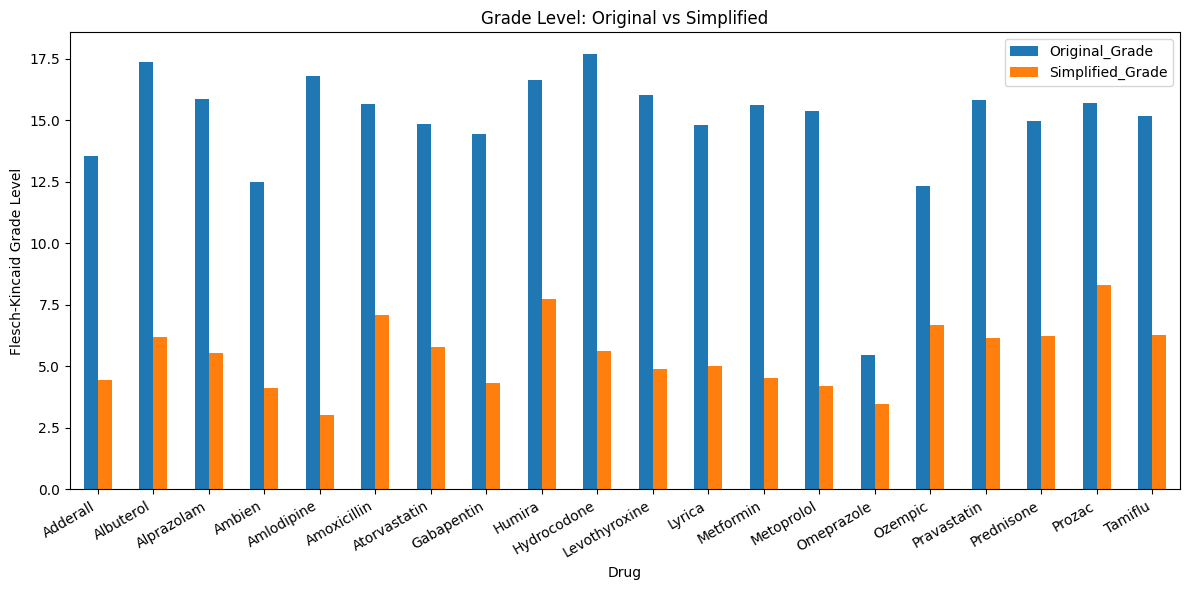

In [55]:
import matplotlib.pyplot as plt

ax = df.groupby("Drug")[["Original_Grade", "Simplified_Grade"]].mean().plot(
kind="bar", figsize=(12, 6))

ax.set_title("Grade Level: Original vs Simplified")
ax.set_ylabel("Flesch-Kincaid Grade Level")
ax.set_xlabel("Drug")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

plt.show()

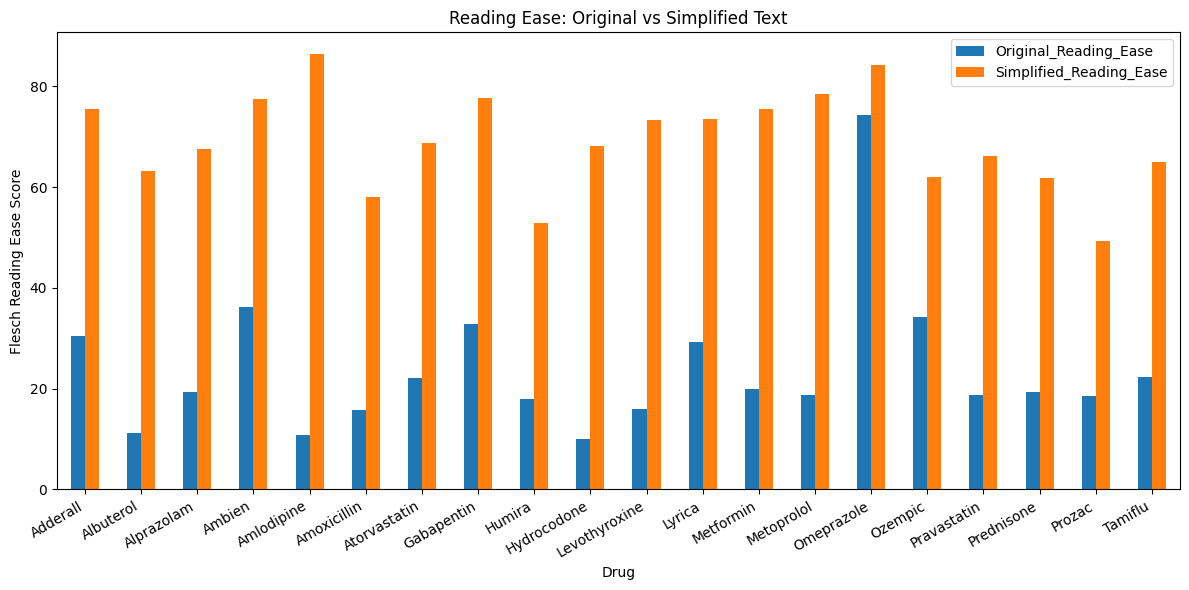

In [56]:
#Plot Reading Ease
ax = df.groupby("Drug")[["Original_Reading_Ease", "Simplified_Reading_Ease"]].mean().plot(kind="bar",
figsize=(12, 6))

ax.set_title("Reading Ease: Original vs Simplified Text")
ax.set_ylabel("Flesch Reading Ease Score")
ax.set_xlabel("Drug")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

# Numeric loss check
A numeric loss check is performed to make surethat the important numbers from original text are not changed or removed during simplification. Medication instructions include important numbers like dosages,frequencies, or measurements so it is important to be able to see if model was able to extract all numeric values correctly. If numbers dont match, then marked with 'Yes' and if match marked with 'No'. It had numerical loss but with manual inspection I can see that it was not related to important dosages, frequencies, or measurements. 

In [57]:
import re 
def check_numeric_loss(row):
    original_numbers = set(re.findall(r'\d+', row["Original_Text"]))
    simplified_numbers = set(re.findall(r'\d+', row["Simplified_Text"]))
    return (original_numbers) != simplified_numbers
df["Numeric_Loss"] = df.apply(check_numeric_loss, axis=1)

In [16]:
df_results = df[[
    "Drug",
    "Section",
    "Original_Text",
    "Simplified_Text",
    "Original_Grade",
    "Simplified_Grade",
    "Original_Reading_Ease",
    "Simplified_Reading_Ease",
    "Meaning_Score",
    "Numeric_Loss"
]].copy()

df_results["Numeric_Loss"] = df_results["Numeric_Loss"].map({True:"Yes", False: "No"})

In [18]:
#Create final table

#Round numeric columns to 1 decimal place
df_results = df_results.round({
    "Original_Grade":1, 
    "Simplified_Grade":1, 
    "Original_Reading_Ease":1, 
    "Simplified_Reading_Ease":1,
    "Meaning_Score":1, 
})

df_results.head()

,Drug,Section,Original_Text,Simplified_Text,Original_Grade,Simplified_Grade,Original_Reading_Ease,Simplified_Reading_Ease,Meaning_Score,Numeric_Loss
0,Adderall,Dosage,"Regardless of indication, amphetamines should ...",How to take it: - Take the lowest dose that wo...,11.4,3.7,44.6,82.2,0.9,Yes
1,Adderall,Warnings,"Abuse, Misuse, and Addiction Adderall has a hi...",How to take it: - Adderall can be abused or mi...,15.8,5.3,16.2,68.6,0.9,No
2,Alprazolam,Dosage,Administer alprazolam extended-release tablets...,How to take it: - Take the medicine once daily...,13.9,4.5,27.0,74.9,0.8,No
3,Alprazolam,Warnings,Risks from Concomitant Use with Opioids: Conc...,How to take it: - Do not take with opioids. - ...,17.9,6.6,11.5,60.1,0.8,Yes
4,Metoprolol,Dosage,Hypertension Adults: The usual initial dosage ...,How to take it: - Adults start with 25 mg to 1...,12.9,3.4,35.0,84.4,0.7,No


In [19]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

df_display = df_results[[
    "Drug",
    "Section",
    "Original_Grade",
    "Simplified_Grade",
    "Original_Reading_Ease",
    "Simplified_Reading_Ease",
    "Meaning_Score",
    "Numeric_Loss"
]].copy()


# Plot Meaning Score vs Grade Level Reduction
The graph shows how meaning changes as reading level is reduced. The x-axis represents the grade level reduction after simplification and the y-axis is the meaning score after simplification. Most points are clustered around .70 - .95, even when grade level is reduced significantly. So simplification was mostly successful. There is some points on the lower end of the scale, where the drug was starting at a very high grade level and simplifcation was just too aggressive, making the model lose some of the meaning. However it was only around 2-3 drugs out of the 20. 

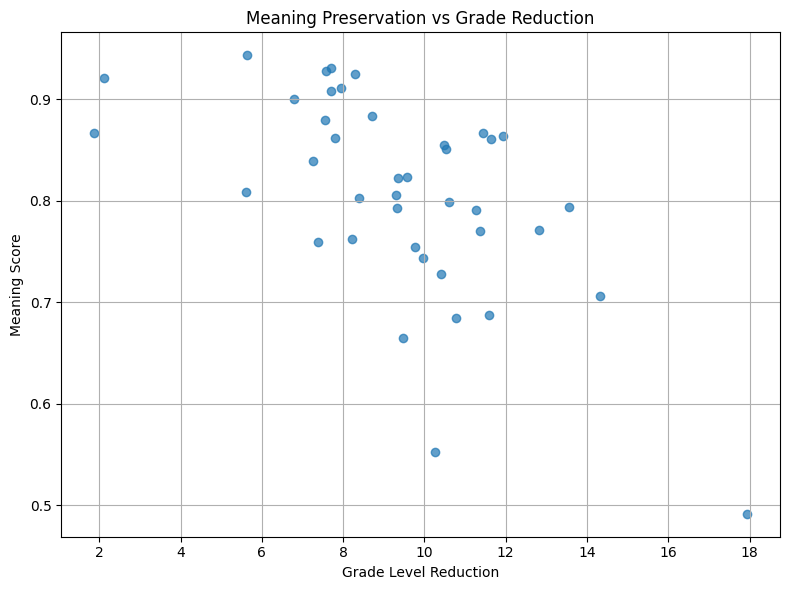

In [61]:
# Calculate how much grade level decreased 
df["Grade_Reduction"] = df["Original_Grade"] - df["Simplified_Grade"]

# Scatter plot
plt.figure(figsize=(8,6))
plt.scatter(df["Grade_Reduction"], df["Meaning_Score"], alpha=.7)

plt.xlabel("Grade Level Reduction")
plt.ylabel("Meaning Score")
plt.title ("Meaning Preservation vs Grade Reduction")

plt.grid(True)
plt.tight_layout()
plt.show()


In [20]:
from IPython.display import display
display(df_display)

,Drug,Section,Original_Grade,Simplified_Grade,Original_Reading_Ease,Simplified_Reading_Ease,Meaning_Score,Numeric_Loss
0,Adderall,Dosage,11.4,3.7,44.6,82.2,0.9,Yes
1,Adderall,Warnings,15.8,5.3,16.2,68.6,0.9,No
2,Alprazolam,Dosage,13.9,4.5,27.0,74.9,0.8,No
3,Alprazolam,Warnings,17.9,6.6,11.5,60.1,0.8,Yes
4,Metoprolol,Dosage,12.9,3.4,35.0,84.4,0.7,No
5,Metoprolol,Warnings,17.9,5.0,2.4,72.6,0.8,No
6,Ozempic,Dosage,9.3,3.7,52.4,84.6,0.9,Yes
7,Ozempic,Warnings,15.3,9.7,16.1,39.4,0.8,Yes
8,Humira,Dosage,16.0,5.5,23.0,68.7,0.9,Yes
9,Humira,Warnings,17.3,9.9,12.9,37.1,0.8,Yes


In [21]:
df.to_csv("../data/processed/final_pipeline_ready.csv", index=False)
df_results.to_csv("../data/processed/final_results_full.csv", index=False)
df_display.to_csv("../data/processed/final_results_table.csv", index=False)